# EuroSAT Land Use and Land Cover Classification
- **Group Members:** Anaushka Goyal, Tyler Maynard
- **Submission Date:** April 5, 2026

---
## 1. Data Loading, Processing, and Exploration

### 1.0 Libraries

In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image as PILImage
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_curve,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from itertools import combinations
import rasterio

### 1.0 Setup

Global configuration: path to the EuroSAT multispectral dataset, accepted file extensions, and a fixed random seed to ensure reproducibility at all steps.

In [2]:
data_dir = Path("C:/Users/tjama/Deep_Learning/EUROSAT/EuroSAT_MS")
image_exts = {".tif"}
seed = 1
random.seed(seed)
np.random.seed(seed)

### 1.1 Data Preparation

**Loading:** A custom load_ms_dataset function iterates over each class subdirectory, reading individual .tif files via rasterio and transposing the native (bands, H, W) format to the (H, W, bands) convention expected by Keras. The resulting dataset is consolidated into a single NumPy array of shape (N, 64, 64, 13) with corresponding integer class labels.

**Exploratory Data Analysis:** Prior to model development, we conduct a brief EDA to report total sample count, class inventory, and per-class distribution. Examining class balance is a critical preliminary step, as skewed distributions can silently bias model training and inflate accuracy metrics, informing whether stratified splitting or class weighting is warranted downstream.

In [3]:
# Define function to load images
# Images are stored as uint16 to halve memory (2.7 GB vs 5.4 GB).
# They are only cast to float32 at the point of computation.
def load_ms_dataset(root: Path):
    subdirs = sorted([d for d in root.iterdir() if d.is_dir()])
    class_names = [d.name for d in subdirs]
    images, labels = [], []

    for class_idx, d in enumerate(subdirs):
        img_paths = sorted([f for f in d.iterdir() if f.suffix.lower() in {".tif", ".tiff"}])
        for path in img_paths:
            with rasterio.open(path) as src:
                img = src.read()              # (13, 64, 64), uint16
            img = np.transpose(img, (1, 2, 0))  # → (64, 64, 13)
            images.append(img)
            labels.append(class_idx)

    return (
        np.array(images, dtype=np.uint16),   # uint16 → ~2.7 GB vs 5.4 GB float32
        np.array(labels, dtype=np.int32),
        class_names,
    )


In [4]:
# Load images and print shapes and classes
images, labels, class_names = load_ms_dataset(data_dir)
print(f"Images shape: {images.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Classes ({len(class_names)}): {class_names}")

Images shape: (27000, 64, 64, 13)
Labels shape: (27000,)
Classes (10): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [5]:
# Print general statistics on images and classes
counts = [int(np.sum(labels == i)) for i in range(len(class_names))]
total = len(labels)

print(f"Total images:  {total:,}")
print(f"Classes: {len(class_names)}")
print(f"Min per class: {min(counts):,} ({class_names[counts.index(min(counts))]})")
print(f"Max per class: {max(counts):,} ({class_names[counts.index(max(counts))]})")
print(f"Average per class: {total // len(class_names):,}")

Total images:  27,000
Classes: 10
Min per class: 2,000 (Pasture)
Max per class: 3,000 (AnnualCrop)
Average per class: 2,700


#### Class Distribution

The class distribution across the EuroSAT dataset is visualised in Figure X. Seven of the ten land cover classes contain 3,000 samples each, while Highway, Industrial, and River contribute 2,500 and Pasture the fewest at 2,000. Although the dataset is not perfectly balanced, the variation is modest at roughly a 1.5x ratio between the largest and smallest classes, suggesting that class imbalance is unlikely to be a dominant source of bias. Nonetheless, stratified splitting is applied throughout to ensure each partition preserves the original class proportions.

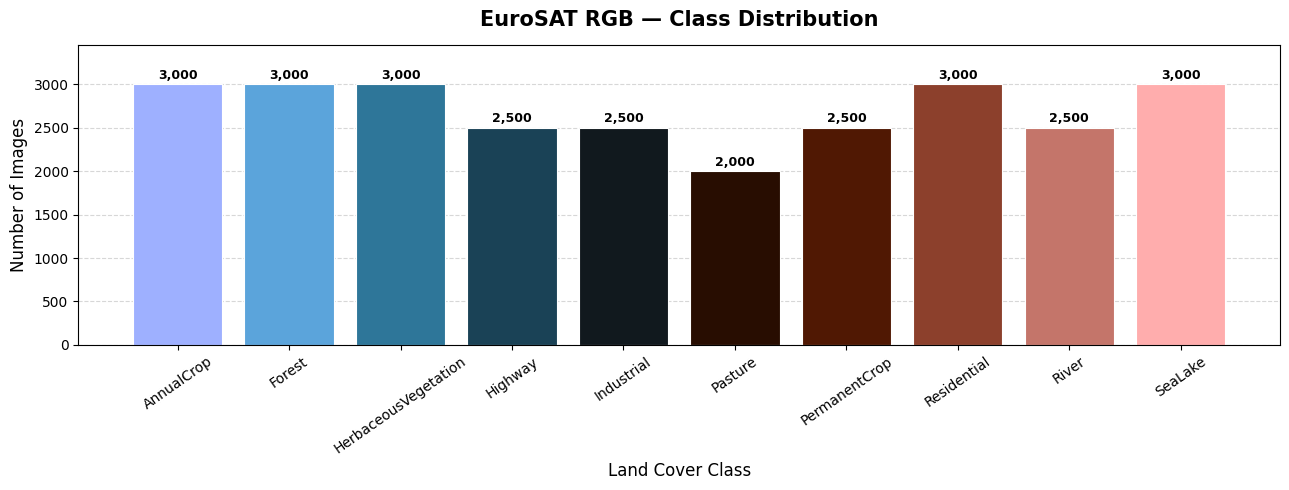

In [6]:
#Plot distribution of classes
fig, ax = plt.subplots(figsize=(13, 5))
colors = plt.cm.berlin(np.linspace(0, 1, len(class_names)))
bars = ax.bar(class_names, counts, color=colors, edgecolor="white", linewidth=0.8)
ax.set_title("EuroSAT RGB — Class Distribution", fontsize=15, fontweight="bold", pad=14)
ax.set_xlabel("Land Cover Class", fontsize=12)
ax.set_ylabel("Number of Images", fontsize=12)
ax.set_ylim(0, max(counts) * 1.15)
ax.tick_params(axis="x", rotation=35)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
for bar, cnt in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(counts) * 0.01,
        f"{cnt:,}",
        ha="center", va="bottom", fontsize=9, fontweight="bold",
    )
plt.tight_layout()
plt.show()

#### RGB Visualization Helper

The ms_to_rgb function extracts bands 3, 2, and 1 (Red, Green, Blue respectively) from the 13-band multispectral array and applies per-channel percentile clipping between the 2nd and 98th percentiles to stretch contrast and suppress outlier reflectance values. The resulting composite provides a visually interpretable approximation of natural colour for qualitative inspection of the imagery. It is important to note that this rendering is used solely for display purposes; all models receive either grayscale-flattened or full 13-band multispectral inputs, preserving the complete spectral information available in the EuroSAT dataset.

In [7]:
def ms_to_rgb(img, bands=(3, 2, 1)):
    rgb = (img / 28000.0)[:, :, list(bands)].astype(np.float32)
    for i in range(3):
        p2, p98 = np.percentile(rgb[:, :, i], (2, 98))
        rgb[:, :, i] = np.clip((rgb[:, :, i] - p2) / (p98 - p2 + 1e-6), 0, 1)
    return rgb

#### One Sample Per Class (2×5 Grid)

The figure below displays one representative pseudo-RGB composite per class arranged in a 2x5 grid, providing qualitative insight into the visual and spectral characteristics that distinguish each land cover type. Several classes exhibit strong inter-class separability even in natural colour, with Residential showing clear geometric building patterns, Pasture and Forest displaying distinct green tonal signatures, and Highway presenting linear infrastructure against vegetated backgrounds.

**NOTE:** The SeaLake composite appears as high-frequency random noise rather than a coherent water body. This is a known artefact of the percentile stretching applied to water pixels, whose reflectance values are extremely low and spectrally flat across the visible bands. The stretching amplifies sensor noise to fill the contrast range, producing the speckled appearance seen above. This does not reflect the true spectral content of the class; the raw band values are well-behaved and SeaLake remains a learnable category for the models.

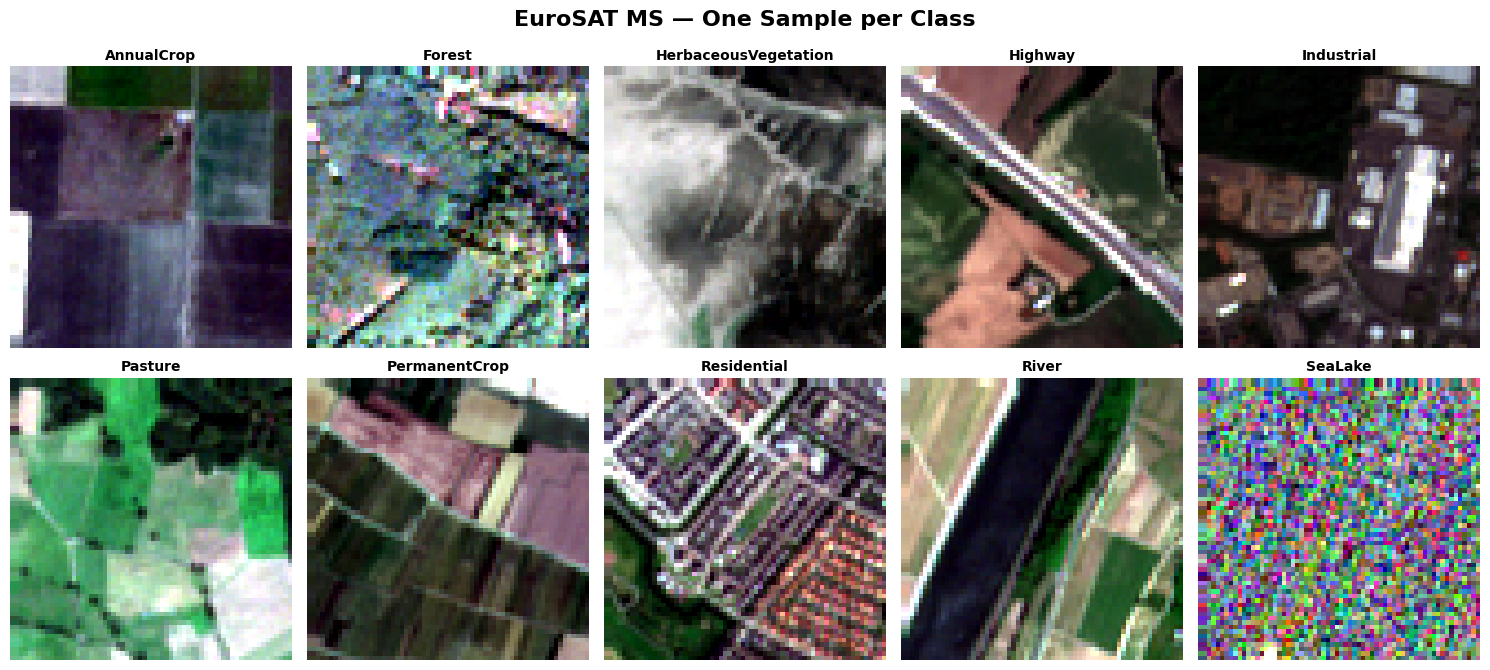

shape: (64, 64, 13)
dtype: uint16
min/max per band:
  band 0: min=1235.0, max=1420.0
  band 1: min=1002.0, max=1534.0
  band 2: min=905.0, max=1664.0
  band 3: min=893.0, max=2297.0
  band 4: min=1034.0, max=2128.0
  band 5: min=1120.0, max=2376.0
  band 6: min=1238.0, max=2689.0
  band 7: min=1186.0, max=2977.0
  band 8: min=353.0, max=631.0
  band 9: min=9.0, max=14.0
  band 10: min=2248.0, max=3490.0
  band 11: min=1236.0, max=2537.0
  band 12: min=1404.0, max=3108.0


In [8]:
# Plot a single image sample per class
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
fig.suptitle("EuroSAT MS — One Sample per Class", fontsize=16, fontweight="bold")

for idx, cls in enumerate(class_names):
    row, col = divmod(idx, 5)
    ax = axes[row][col]
    # Pick first image of this class
    sample_img = images[labels == idx][0]
    ax.imshow(ms_to_rgb(sample_img)) 
    ax.set_title(cls, fontsize=10, fontweight="bold", pad=5)
    ax.axis("off")

plt.tight_layout()
plt.show()


sample = images[0]
print("shape:", sample.shape)
print("dtype:", sample.dtype)
print("min/max per band:")
for i in range(13):
    print(f"  band {i}: min={sample[:,:,i].min():.1f}, max={sample[:,:,i].max():.1f}")

#### Flattening and Normalization

Each `(64, 64, 13)` image is flattened into a 1D vector of length `64 × 64 = 4096` pixels (grayscale) or `64 × 64 × 13 = 53248` (full MS), producing a 2D data matrix of shape `(N, p)` required by sklearn classifiers. Pixel values are normalized to `[0, 1]` by dividing by the sensor's approximate maximum reflectance value of 28,000.

In [9]:
# Compute flattened float32 feature matrix on-the-fly (never stored alongside images)
X = (images.reshape(len(images), -1).astype(np.float32)) / 28000.0
y = labels.copy()

print(f"X shape (n × p): {X.shape}")
print(f"y shape        : {y.shape}")
print(f"Pixel range    : [{X.min():.2f}, {X.max():.2f}]")
print(f"images dtype   : {images.dtype}  (uint16, ~{images.nbytes/1e9:.2f} GB)")
# del X  # free immediately — we only needed it for the stat print above


X shape (n × p): (27000, 53248)
y shape        : (27000,)
Pixel range    : [0.00, 1.00]
images dtype   : uint16  (uint16, ~2.88 GB)


#### Train / Test Split

The dataset is split 60% train / 40% test using stratified sampling (`stratify=y`) to ensure each class is proportionally represented in both sets. The same split is applied to both the flattened feature matrix `X` and the raw image array `images` (needed for deep learning sections). A balance check is printed to confirm stratification was applied correctly.

In [10]:
# Split train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.4,
    stratify=y,
    random_state=seed,
)

# Also keep the raw image arrays for deep learning sections
images_train, images_test, _, _ = train_test_split(
    images, y,
    test_size=0.4,
    stratify=y,
    random_state=seed,
)

print(f"Train — X: {X_train.shape}, y: {y_train.shape}")
print(f"Test  — X: {X_test.shape},  y: {y_test.shape}")

# Verify stratification for class balance
train_counts = [int(np.sum(y_train == i)) for i in range(len(class_names))]
test_counts  = [int(np.sum(y_test  == i)) for i in range(len(class_names))]
print("\nClass balance check:")
print(f"  {'Class':<26} {'Train':>6}  {'Test':>6}")
for cls, tr, te in zip(class_names, train_counts, test_counts):
    print(f"  {cls:<26} {tr:>6}  {te:>6}")

Train — X: (16200, 53248), y: (16200,)
Test  — X: (10800, 53248),  y: (10800,)

Class balance check:
  Class                       Train    Test
  AnnualCrop                   1800    1200
  Forest                       1800    1200
  HerbaceousVegetation         1800    1200
  Highway                      1500    1000
  Industrial                   1500    1000
  Pasture                      1200     800
  PermanentCrop                1500    1000
  Residential                  1800    1200
  River                        1500    1000
  SeaLake                      1800    1200


#### Grayscale Conversion

A grayscale version of the dataset is created using ITU-R BT.601 luminance weights (`Y = 0.299R + 0.587G + 0.114B`) applied to the RGB bands (3, 2, 1). This reduces each image from 13 bands to a single channel, producing a `(N, 64, 64)` array and requiring significantly less memory. The grayscale images are then flattened and normalized to `[0, 1]`, yielding a feature matrix of shape `(N, 4096)`. This grayscale representation is used for all traditional ML models and the early deep learning models.

In [11]:
# ITU-R BT.601 luminance weights: Y = 0.299R + 0.587G + 0.114B
# Returns uint8 [0-255] to keep memory low.
def to_grayscale_ms(img_array: np.ndarray) -> np.ndarray:
    """Extract RGB bands (3,2,1) from MS uint16 and apply luminance weights.
    Returns uint8 array of shape (N, 64, 64)."""
    # Process in chunks to avoid a large temporary float32 intermediate
    N = len(img_array)
    out = np.empty((N, img_array.shape[1], img_array.shape[2]), dtype=np.uint8)
    chunk = 1000
    weights = np.array([0.299, 0.587, 0.114], dtype=np.float32)
    for start in range(0, N, chunk):
        end = min(start + chunk, N)
        rgb = img_array[start:end, :, :, [3, 2, 1]].astype(np.float32) / 28000.0
        gray = rgb @ weights  # (chunk, 64, 64)
        out[start:end] = (np.clip(gray, 0, 1) * 255).astype(np.uint8)
    return out

images_gray = to_grayscale_ms(images)  # uint8, (27000, 64, 64) ≈ 0.11 GB

# Flattened + normalised grayscale matrix
X_gray = images_gray.reshape(len(images_gray), -1).astype(np.float32) / 255.0

# Split grayscale with same indices as main split
X_gray_train, X_gray_test, _, _ = train_test_split(
    X_gray, y,
    test_size=0.4,
    stratify=y,
    random_state=seed,
)
print(f"images_gray dtype: {images_gray.dtype}  shape: {images_gray.shape}  ({images_gray.nbytes/1e9:.2f} GB)")
print(f"X_gray_train: {X_gray_train.shape}")


images_gray dtype: uint8  shape: (27000, 64, 64)  (0.11 GB)
X_gray_train: (16200, 4096)


### 1.2 Data Augmentation

Data augmentation is applied **after** the train/test split to prevent data leakage — augmented versions of training images must never appear in the test set.

**Augmentation techniques applied:**
- **Horizontal flip:** mirrors each image left-to-right
- **Vertical flip:** mirrors each image top-to-bottom
- **90° rotation:** rotates each image by 90 degrees

Each technique is applied to every image, so the augmented dataset is **4× the original size** (original + 3 augmented versions). The augmented samples are then shuffled to intersperse originals and augmented copies throughout the dataset.

These geometric transforms are appropriate for satellite imagery because land cover classes are rotation- and reflection-invariant — a forest looks the same from any orientation.

In [12]:
# Define function to augment images
# Works on any integer or float array — keeps the input dtype to avoid
# silent upcasting to float64 and the associated memory explosion.
def augment_dataset(
    imgs: np.ndarray,
    lbls: np.ndarray,
    seed: int = seed,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Apply horizontal flip, vertical flip, and 90-degree rotation
    to every image, 4× the dataset size (original + 3 augmented).
    Preserves input dtype (uint16, uint8, etc.).
    """
    rng = np.random.default_rng(seed)

    h_flip = imgs[:, :, ::-1, ...]          # horizontal flip
    v_flip = imgs[:, ::-1, :, ...]          # vertical flip
    rot90  = np.rot90(imgs, k=1, axes=(1, 2))  # 90° rotation

    aug_imgs = np.concatenate([imgs, h_flip, v_flip, rot90], axis=0)
    aug_lbls = np.concatenate([lbls, lbls, lbls, lbls], axis=0)

    idx = rng.permutation(len(aug_imgs))
    return aug_imgs[idx], aug_lbls[idx]


images_aug_train, y_aug_train = augment_dataset(images_train, y_train)

print(f"Original train size  : {len(images_train):,}")
print(f"Augmented train size : {len(images_aug_train):,}  (4× original)")
print(f"images_aug_train dtype: {images_aug_train.dtype}  ({images_aug_train.nbytes/1e9:.2f} GB)")

Original train size  : 16,200
Augmented train size : 64,800  (4× original)
images_aug_train dtype: uint16  (6.90 GB)


#### Post-Augmentation Class Distribution

The bar chart below confirms that class balance is realtively preserved after augmentation, since every image is augmented equally, the relative proportions across classes remain comparable to the original distribution.

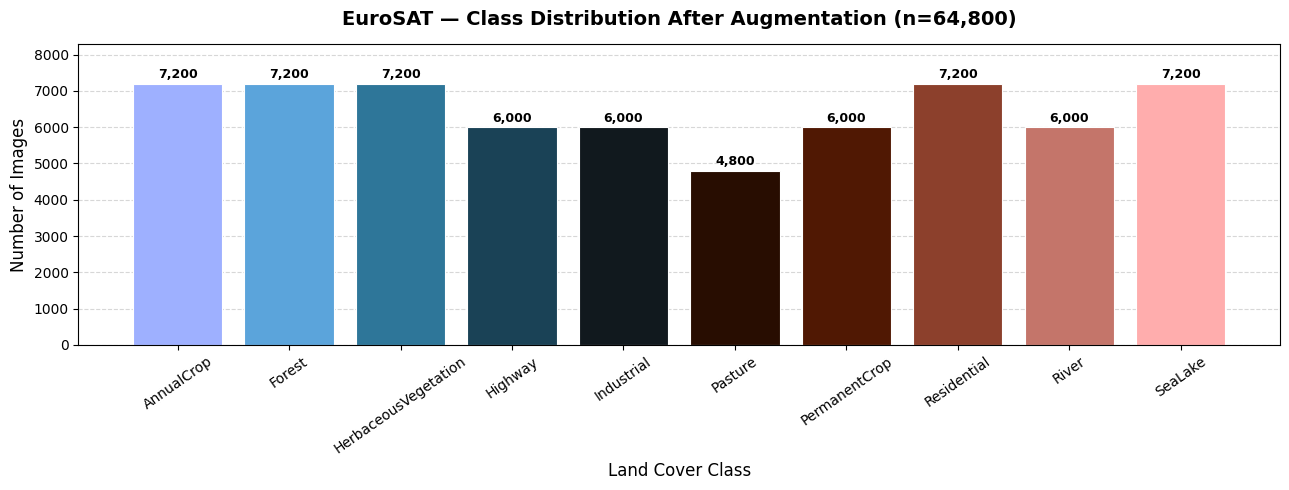

In [13]:
# Plot distribution of classes post-augmentation of images
aug_counts = [int(np.sum(y_aug_train == i)) for i in range(len(class_names))]

fig, ax = plt.subplots(figsize=(13, 5))
colors = plt.cm.berlin(np.linspace(0, 1, len(class_names)))
bars = ax.bar(class_names, aug_counts, color=colors, edgecolor="white", linewidth=0.8)
ax.set_title(
    f"EuroSAT — Class Distribution After Augmentation (n={len(images_aug_train):,})",
    fontsize=14, fontweight="bold", pad=14,
)
ax.set_xlabel("Land Cover Class", fontsize=12)
ax.set_ylabel("Number of Images", fontsize=12)
ax.set_ylim(0, max(aug_counts) * 1.15)
ax.tick_params(axis="x", rotation=35)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
for bar, cnt in zip(bars, aug_counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(aug_counts) * 0.01,
        f"{cnt:,}",
        ha="center", va="bottom", fontsize=9, fontweight="bold",
    )
plt.tight_layout()
plt.show()

#### Random Augmented Sample Visualization

Three randomly selected images from the augmented dataset are displayed to visually confirm that augmentation was applied correctly and that labels are preserved.

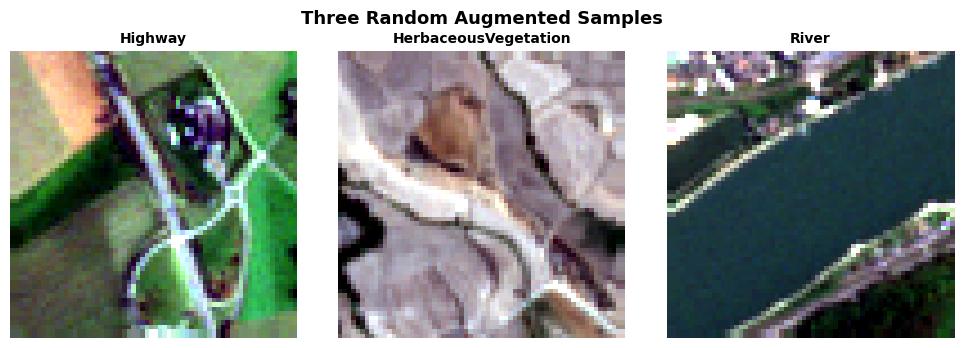

In [14]:
# Plot random augmented image samples
rng = np.random.default_rng(seed)
sample_idx = rng.choice(len(images_aug_train), size=3, replace=False)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
fig.suptitle("Three Random Augmented Samples", fontsize=13, fontweight="bold")
for ax, idx in zip(axes, sample_idx):
    ax.imshow(ms_to_rgb(images_aug_train[idx], bands=(3, 2, 1)))
    ax.set_title(class_names[y_aug_train[idx]], fontsize=10, fontweight="bold")
    ax.axis("off")
plt.tight_layout()
plt.show()

#### Final Augmented Train/Test Split

The augmented dataset is split into train (60%) and test (40%) sets using the same stratified strategy as before. Both flattened RGB and grayscale feature matrices are prepared here, along with raw image arrays for use in deep learning sections.

In [15]:
# NOTE: We no longer store giant flattened float32 matrices for the full MS dataset.
# Flattened matrices are computed on-demand inside each model's training cell.
# This cell preserves only the raw image arrays and label vectors.

y_aug_test = y_test  # test labels unchanged

print("Dataset summary (raw arrays):")
print(f"  images_aug_train : {images_aug_train.shape}  dtype={images_aug_train.dtype}  ({images_aug_train.nbytes/1e9:.2f} GB)")
print(f"  images_test      : {images_test.shape}  dtype={images_test.dtype}  ({images_test.nbytes/1e9:.2f} GB)")
print(f"  y_aug_train      : {y_aug_train.shape}")
print(f"  y_aug_test       : {y_aug_test.shape}")


Dataset summary (raw arrays):
  images_aug_train : (64800, 64, 64, 13)  dtype=uint16  (6.90 GB)
  images_test      : (10800, 64, 64, 13)  dtype=uint16  (1.15 GB)
  y_aug_train      : (64800,)
  y_aug_test       : (10800,)


#### Variable Reference

The table below summarizes all key variables produced by the data preparation pipeline:

| Variable | Shape | Description |
|---|---|---|
| `images_aug_train / _test` | (N, 64, 64, 13) | Raw multispectral images |
| `X_aug_train / _test` | (N, 53248) | Flattened, normalized RGB float32 |
| `X_gray_aug_train / _test` | (N, 4096) | Flattened, normalized grayscale float32 |
| `images_gray_aug_train / _test` | (N, 64, 64) | Raw grayscale image arrays |
| `y_aug_train / _test` | (N,) | Integer class labels (0–9) |
| `class_names` | list[str] | 10 land cover class name strings |

In [16]:
def to_grayscale(imgs: np.ndarray) -> np.ndarray:
    """Convert uint16 MS images to float32 grayscale [0,1] using BT.601 on RGB bands.
    Processes in chunks to avoid a large temporary float32 copy in memory."""
    weights = np.array([0.299, 0.587, 0.114], dtype=np.float32)
    N = len(imgs)
    out = np.empty((N, imgs.shape[1], imgs.shape[2]), dtype=np.float32)
    chunk = 2000
    for start in range(0, N, chunk):
        end = min(start + chunk, N)
        rgb = imgs[start:end, :, :, :3].astype(np.float32) / 28000.0
        out[start:end] = rgb @ weights
    return np.clip(out, 0, 1)


In [17]:
# Grayscale raw image arrays for augmented dataset
# float32 [0,1]; shape (N, 64, 64) — ~1.07 GB for train, ~0.71 GB for test
images_gray_aug_train = to_grayscale(images_aug_train)
images_gray_aug_test  = to_grayscale(images_test)

print(f"images_gray_aug_train: {images_gray_aug_train.shape}  ({images_gray_aug_train.nbytes/1e9:.2f} GB)")
print(f"images_gray_aug_test : {images_gray_aug_test.shape}  ({images_gray_aug_test.nbytes/1e9:.2f} GB)")


images_gray_aug_train: (64800, 64, 64)  (1.06 GB)
images_gray_aug_test : (10800, 64, 64)  (0.18 GB)


---
## 2. Traditional Machine Learning

For this section, we focus on three land cover classes: **Forest (F)**, **Industrial (I)**, and **Residential (R)**. We subset the grayscale augmented dataset to include only these three classes and remap their labels to `{0: Forest, 1: Industrial, 2: Residential}`.

All models in this section use PCA-reduced grayscale features (`X_tr_pca`, `X_te_pca`) to reduce the 4096-dimensional input to 256 principal components, retaining ~90%+ of variance while significantly reducing training time.

### 2.1 Binary Support Vector Machine

**Approach:** Three binary LinearSVC classifiers are trained, one for each pair of classes: [F vs R], [F vs I], and [R vs I]. This one-vs-one strategy is a standard decomposition of multiclass problems into binary subproblems.

**PCA preprocessing:** Before fitting, the 4096-dimensional grayscale features are reduced to 256 components via PCA. This is fit on training data only and applied to both train and test sets to prevent leakage.

**Evaluation:** For each classifier we report accuracy and plot the ROC curve with AUC. ROC curves are computed using `decision_function` scores (signed distance from the hyperplane), which serve as a valid ranking score for AUC without requiring probability calibration.

One misclassified test image is shown per classifier, with its true and predicted label.

In [18]:
# images_gray_aug_train / _test are already float32 [0,1] from to_grayscale()
# We just reshape to (N, 4096) — no copy needed.
X_gray_aug_train = images_gray_aug_train.reshape(len(images_gray_aug_train), -1)
X_gray_aug_test  = images_gray_aug_test.reshape(len(images_gray_aug_test), -1)

print(f"X_gray_aug_train: {X_gray_aug_train.shape}  dtype={X_gray_aug_train.dtype}")
print(f"X_gray_aug_test : {X_gray_aug_test.shape}  dtype={X_gray_aug_test.dtype}")
print(f"Memory: {X_gray_aug_train.nbytes/1e9:.2f} GB (train) + {X_gray_aug_test.nbytes/1e9:.2f} GB (test)")


X_gray_aug_train: (64800, 4096)  dtype=float32
X_gray_aug_test : (10800, 4096)  dtype=float32
Memory: 1.06 GB (train) + 0.18 GB (test)


In [19]:
TARGET_CLASSES = ["Forest", "Industrial", "Residential"]
target_idx = [class_names.index(c) for c in TARGET_CLASSES]
label_map = {orig: new for new, orig in enumerate(target_idx)}  # remap to 0,1,2
short = {0: "F", 1: "I", 2: "R"}  # short labels for plots

def subset(X, y, imgs):
    mask = np.isin(y, target_idx)
    X_s = X[mask]
    y_s = np.array([label_map[yi] for yi in y[mask]])
    imgs_s = imgs[mask]
    return X_s, y_s, imgs_s

X_tr, y_tr, imgs_tr = subset(X_gray_aug_train, y_aug_train, images_gray_aug_train)
X_te, y_te, imgs_te = subset(X_gray_aug_test,  y_test,      images_gray_aug_test)

print(f"Train: {X_tr.shape}, Test: {X_te.shape}")
for i, c in enumerate(TARGET_CLASSES):
    print(f"  {c}: train={np.sum(y_tr==i)}, test={np.sum(y_te==i)}")

Train: (20400, 4096), Test: (3400, 4096)
  Forest: train=7200, test=1200
  Industrial: train=6000, test=1000
  Residential: train=7200, test=1200


#### Helper: Display Misclassified Image

`show_misclassified` finds the first incorrectly classified sample in the provided subset and displays it with the true and predicted class labels annotated in red.

In [20]:
# Helper: show one misclassified image
def show_misclassified(ax, imgs, y_true, y_pred, class_labels):
    wrong = np.where(y_true != y_pred)[0]
    if len(wrong) == 0:
        ax.set_title("No errors!"); ax.axis("off"); return
    idx = wrong[0]
    ax.imshow(imgs[idx], cmap="gray")
    ax.set_title(
        f"True: {class_labels[y_true[idx]]}\nPred: {class_labels[y_pred[idx]]}",
        fontsize=9, color="red"
    )
    ax.axis("off")

#### PCA Dimensionality Reduction + Binary SVM Training

PCA is fit on `X_tr` (training data only) and used to project both train and test sets to 256 dimensions. For each class pair, a `LinearSVC` is trained on the relevant binary subset. Decision scores on the **full** test set are stored in `binary_preds` for use in section 2.2.

Fitting PCA...
Variance retained: 0.926
Starting FvR...
[F vs R] Accuracy: 0.9683   AUC: 0.9899
Starting FvI...
[F vs I] Accuracy: 0.9905   AUC: 0.9993
Starting RvI...
[R vs I] Accuracy: 0.8155   AUC: 0.8977


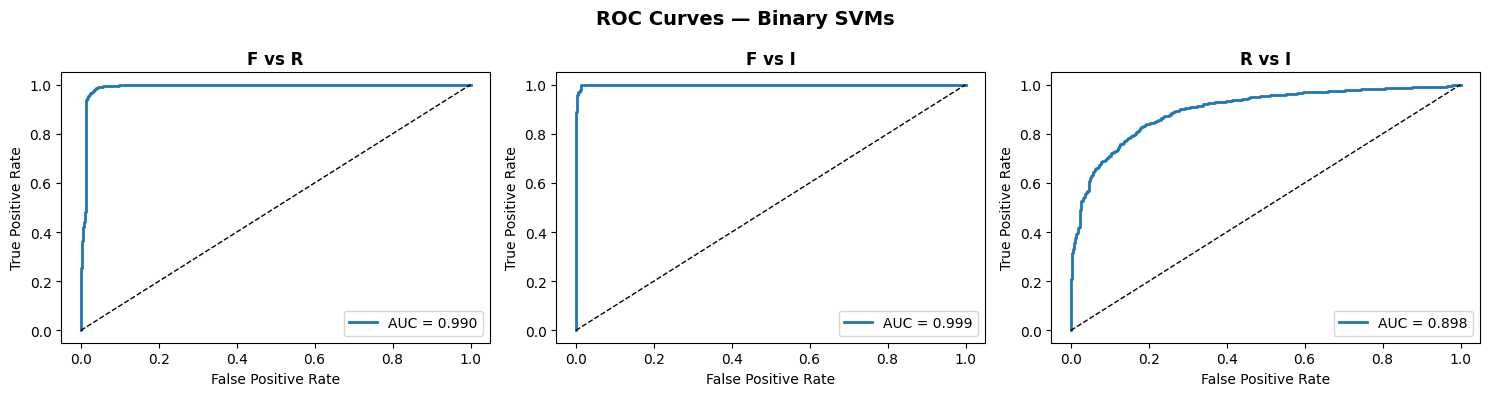

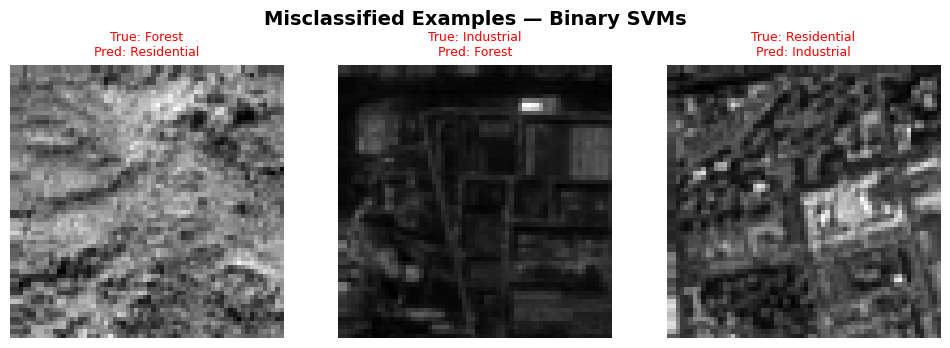

In [21]:
from sklearn.decomposition import PCA
from sklearn.svm import LinearSVC
from sklearn.metrics import roc_curve, auc, accuracy_score

# --- PCA ---
print("Fitting PCA...")
pca = PCA(n_components=256, random_state=42)
X_tr_pca = pca.fit_transform(X_tr)
X_te_pca = pca.transform(X_te)
print(f"Variance retained: {pca.explained_variance_ratio_.sum():.3f}")

# --- Binary SVMs ---
pairs = [(0, 2, "F", "R"), (0, 1, "F", "I"), (2, 1, "R", "I")]
binary_svms = {}
binary_preds = {}

fig_roc, ax_roc = plt.subplots(1, 3, figsize=(15, 4))
fig_mis, ax_mis = plt.subplots(1, 3, figsize=(10, 3.5))

fig_roc.suptitle("ROC Curves — Binary SVMs", fontsize=14, fontweight="bold")
fig_mis.suptitle("Misclassified Examples — Binary SVMs", fontsize=14, fontweight="bold")

for col, (ia, ib, la, lb) in enumerate(pairs):
    pair_key = f"{la}v{lb}"
    print(f"Starting {pair_key}...")

    mask = np.isin(y_tr, [ia, ib])
    X_bin_tr = X_tr_pca[mask]
    y_bin_tr = (y_tr[mask] == ib).astype(int)

    mask_te = np.isin(y_te, [ia, ib])
    X_bin_te = X_te_pca[mask_te]
    y_bin_te = (y_te[mask_te] == ib).astype(int)
    imgs_bin_te = imgs_te[mask_te]
    y_orig_te = y_te[mask_te]

    svm = LinearSVC(max_iter=2000)
    svm.fit(X_bin_tr, y_bin_tr)

    y_pred_bin = svm.predict(X_bin_te)
    y_scores_bin = svm.decision_function(X_bin_te)

    acc = accuracy_score(y_bin_te, y_pred_bin)
    fpr, tpr, _ = roc_curve(y_bin_te, y_scores_bin)
    roc_auc = auc(fpr, tpr)

    print(f"[{la} vs {lb}] Accuracy: {acc:.4f}   AUC: {roc_auc:.4f}")

    ax_roc[col].plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
    ax_roc[col].plot([0, 1], [0, 1], "k--", lw=1)
    ax_roc[col].set_title(f"{la} vs {lb}", fontsize=12, fontweight="bold")
    ax_roc[col].set_xlabel("False Positive Rate")
    ax_roc[col].set_ylabel("True Positive Rate")
    ax_roc[col].legend(loc="lower right")

    y_pred_orig = np.where(y_pred_bin == 0, ia, ib)
    show_misclassified(ax_mis[col], imgs_bin_te, y_orig_te, y_pred_orig, TARGET_CLASSES)
    ax_mis[col].set_xlabel(f"{la} vs {lb}", fontsize=10)

    scores_all = svm.decision_function(X_te_pca)
    pred_all = svm.predict(X_te_pca)

    binary_svms[pair_key] = svm
    binary_preds[pair_key] = (pred_all, scores_all, ia, ib)

plt.figure(fig_roc.number)
plt.tight_layout()

plt.figure(fig_mis.number)
plt.tight_layout()

plt.show()

The above graphs presents ROC curves for the three binary SVM classifiers trained on pairwise class combinations. The Forest vs Industrial (F vs I) classifier achieves the highest AUC of 0.999, indicating near-perfect separability between the two classes, which is expected given their highly distinct spectral and spatial signatures. Forest vs Residential (F vs R) also performs strongly with an AUC of 0.990, reflecting that dense vegetation and urban built-up areas are readily distinguishable in the feature space. However, such a high AUC raises a flag regarding overfitting.

The Residential vs Industrial (R vs I) classifier proves notably more challenging, yielding an AUC of 0.898. This lower score is consistent with the visual and spectral similarity between the two classes. Both contain man-made structures, impervious surfaces, and similar reflectance profiles, making them harder to separate without finer spatial or contextual cues. The smoother, more gradual curve for R vs I further illustrates that the classifier operates with less confidence across decision thresholds compared to the near-vertical curves of the other two pairs.

Overall, all three classifiers perform well above the random baseline (AUC = 0.5), confirming that SVMs trained on flattened pixel features can effectively discriminate between spectrally distinct land cover classes, while highlighting the inherent difficulty of separating visually similar urban categories.

### 2.2 Multiclass, Majority-Vote SVM

**Approach:** The three binary SVMs from section 2.1 are combined into a three-class classifier using majority voting. Each binary classifier casts one vote per test sample for the class it predicts; the final label is the class that receives the most votes (2 out of 3 at most).

**ROC curves:** Since majority voting produces hard labels rather than probabilities, we compute a soft score for each class by aggregating normalized decision scores from all binary SVMs that involve that class. Scores are z-normalized before summing to prevent scale imbalance between classifiers from distorting the ranking.

**Evaluation:** Overall accuracy, per-class OvR ROC curves with AUC, and one misclassified example per class are reported.

Majority-Vote SVM Accuracy: 0.8582


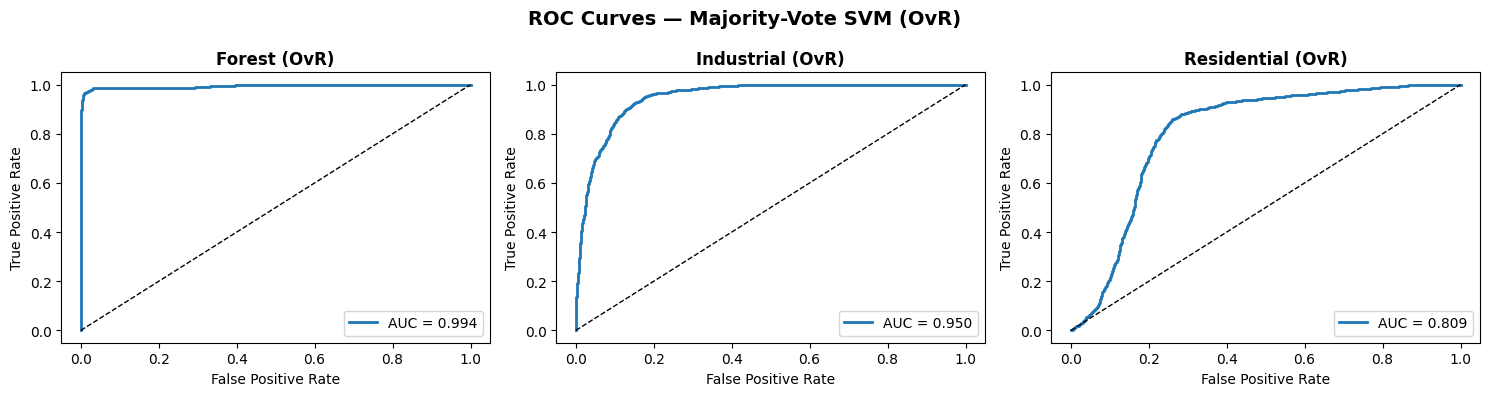

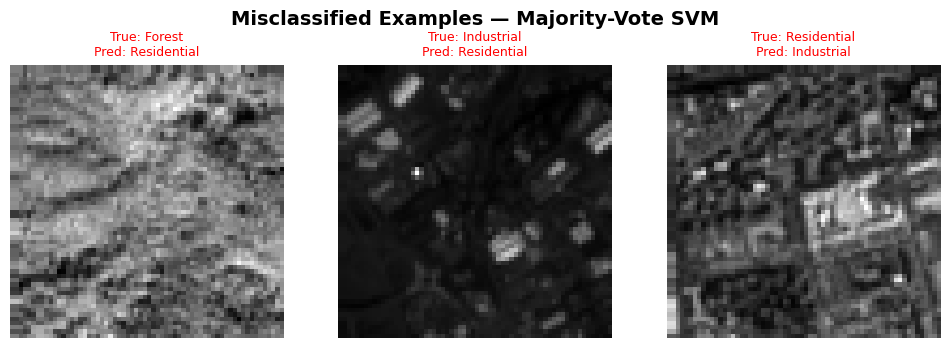

In [22]:
# --- 2.2 Majority-Vote SVM ---

def majority_vote(binary_preds, X_te_pca, n_classes=3):
    """
    For each test sample, collect votes from all 3 binary SVMs,
    then pick the class with the most votes.
    """
    n_samples = X_te_pca.shape[0]
    vote_counts = np.zeros((n_samples, n_classes), dtype=int)

    for pair_key, (pred_all, scores_all, ia, ib) in binary_preds.items():
        # pred_all is 0 or 1 (binary), map back to original class indices
        for i, p in enumerate(pred_all):
            vote_counts[i, ib if p == 1 else ia] += 1

    return np.argmax(vote_counts, axis=1)


y_mv_pred = majority_vote(binary_preds, X_te_pca)

mv_acc = accuracy_score(y_te, y_mv_pred)
print(f"Majority-Vote SVM Accuracy: {mv_acc:.4f}")

# --- ROC curves (one-vs-rest, using summed scores as proxy) ---
fig_roc, ax_roc = plt.subplots(1, 3, figsize=(15, 4))
fig_roc.suptitle("ROC Curves — Majority-Vote SVM (OvR)", fontsize=14, fontweight="bold")

for cls_idx, cls_name in enumerate(TARGET_CLASSES):
    # Aggregate scores for this class from all binary SVMs that involve it
    score_sum = np.zeros(len(y_te))
    for pair_key, (pred_all, scores_all, ia, ib) in binary_preds.items():
        if cls_idx not in (ia, ib):
            continue
        # Normalize scores to [-1, 1] range before summing
        s = scores_all
        s_norm = (s - s.mean()) / (s.std() + 1e-8)
        if cls_idx == ib:
            score_sum += s_norm
        elif cls_idx == ia:
            score_sum -= s_norm

    y_bin_ovr = (y_te == cls_idx).astype(int)
    fpr, tpr, _ = roc_curve(y_bin_ovr, score_sum)
    roc_auc = auc(fpr, tpr)

    ax_roc[cls_idx].plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
    ax_roc[cls_idx].plot([0, 1], [0, 1], "k--", lw=1)
    ax_roc[cls_idx].set_title(f"{cls_name} (OvR)", fontsize=12, fontweight="bold")
    ax_roc[cls_idx].set_xlabel("False Positive Rate")
    ax_roc[cls_idx].set_ylabel("True Positive Rate")
    ax_roc[cls_idx].legend(loc="lower right")

plt.tight_layout()
plt.show()

# --- Misclassified images (one per class) ---
fig_mis, ax_mis = plt.subplots(1, 3, figsize=(10, 3.5))
fig_mis.suptitle("Misclassified Examples — Majority-Vote SVM", fontsize=14, fontweight="bold")

for cls_idx, cls_name in enumerate(TARGET_CLASSES):
    # Only show samples whose true class is cls_idx
    mask = (y_te == cls_idx)
    show_misclassified(ax_mis[cls_idx], imgs_te[mask], y_te[mask], y_mv_pred[mask], TARGET_CLASSES)
    ax_mis[cls_idx].set_xlabel(cls_name, fontsize=10)

plt.tight_layout()
plt.show()

The above figure presents the One-vs-Rest (OvR) ROC curves for the majority-vote SVM evaluated across the three target classes. Forest achieves the highest AUC of 0.994, consistent with its spectrally distinct signature relative to all other land cover types, making it reliably separable in a one-against-all setting.

Industrial drops to an AUC of 0.950, reflecting the increased difficulty of distinguishing industrial areas from the full diversity of remaining classes. While industrial land is visually separable from vegetation-dominated classes, its spectral overlap with other impervious surface categories introduces more ambiguity than in the isolated binary case.

Residential proves the most challenging with an AUC of 0.809, the lowest of the three. This is consistent with findings from the binary classifiers and reinforces that residential areas share structural and spectral characteristics with multiple other classes, particularly Industrial, making clean separation harder in a multiclass context. The notably shallower curve compared to Forest and Industrial further illustrates that the classifier operates with reduced confidence across decision thresholds for this class.

Comparing these results to the binary SVMs, the OvR AUCs are generally lower, which is expected since each classifier must now contend with a broader and more heterogeneous set of negative examples rather than a single contrasting class.

### 2.3 Multiclass Random Forest

**Approach:** A `RandomForestClassifier` with 200 trees is trained directly on the 3-class subset using the same PCA-reduced features (`X_tr_pca`). Random forests are an ensemble of decision trees that aggregate predictions by majority vote, providing native multiclass support and probability estimates via `predict_proba`.

**Why Random Forest here:** Unlike the binary SVMs above, the random forest handles all three classes in a single model, capturing interactions between classes that pairwise classifiers may miss. `n_jobs=-1` parallelizes tree building across all CPU cores for efficiency.

**Evaluation:** Overall accuracy, confusion matrix, per-class OvR ROC curves with AUC, and one misclassified example per class are reported.

Random Forest Accuracy: 0.9535


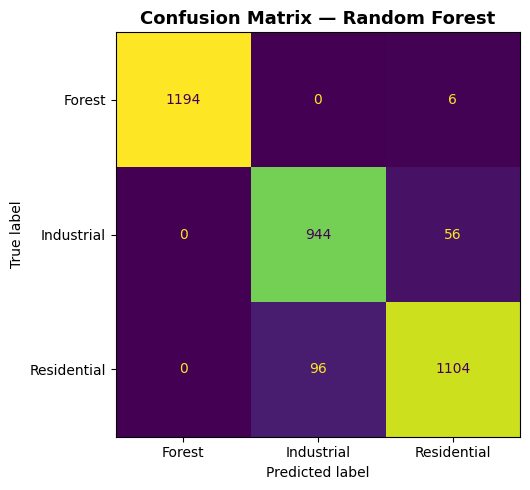

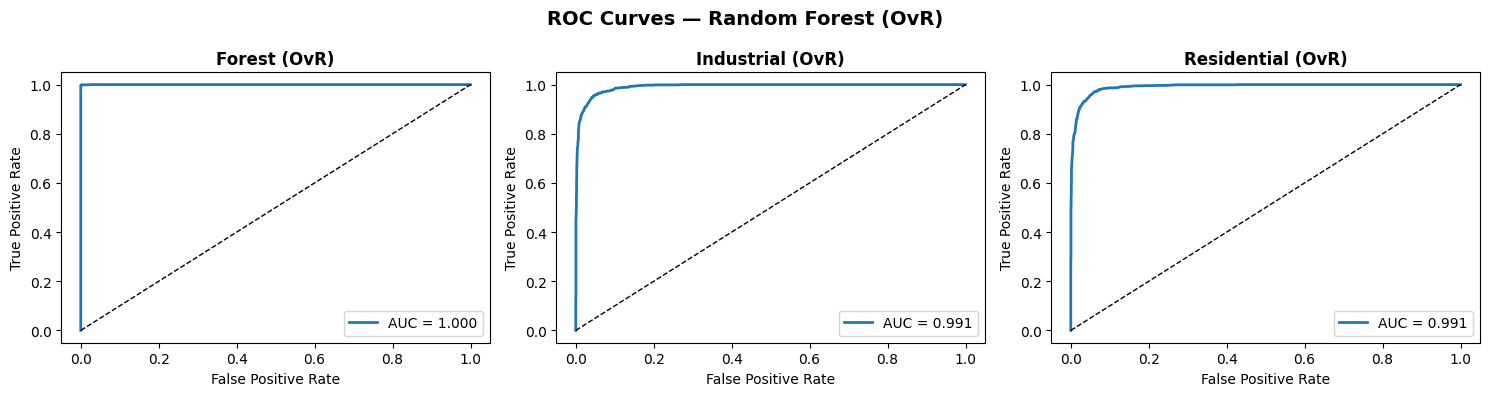

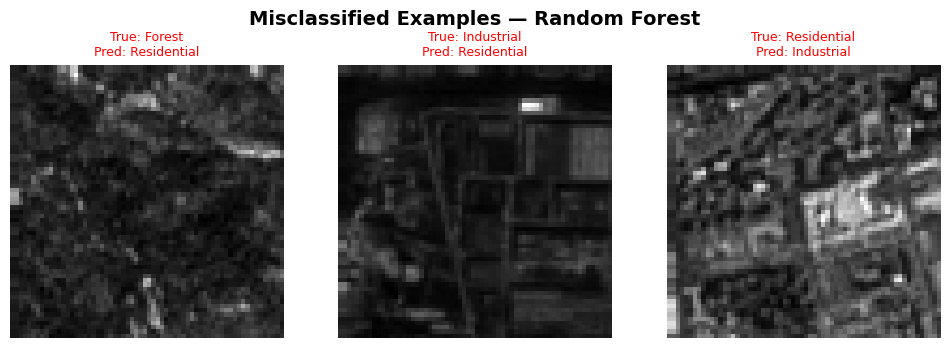

In [23]:
# --- 2.3 Random Forest ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_tr_pca, y_tr)   # reuse same PCA features

y_rf_pred = rf.predict(X_te_pca)
y_rf_proba = rf.predict_proba(X_te_pca)   # shape (n_samples, 3)

rf_acc = accuracy_score(y_te, y_rf_pred)
print(f"Random Forest Accuracy: {rf_acc:.4f}")

# --- Confusion matrix ---
cm = confusion_matrix(y_te, y_rf_pred)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=TARGET_CLASSES).plot(ax=ax, colorbar=False)
ax.set_title("Confusion Matrix — Random Forest", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# --- ROC curves (one-vs-rest) ---
fig_roc, ax_roc = plt.subplots(1, 3, figsize=(15, 4))
fig_roc.suptitle("ROC Curves — Random Forest (OvR)", fontsize=14, fontweight="bold")

for cls_idx, cls_name in enumerate(TARGET_CLASSES):
    y_bin_ovr = (y_te == cls_idx).astype(int)
    fpr, tpr, _ = roc_curve(y_bin_ovr, y_rf_proba[:, cls_idx])
    roc_auc = auc(fpr, tpr)

    ax_roc[cls_idx].plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
    ax_roc[cls_idx].plot([0, 1], [0, 1], "k--", lw=1)
    ax_roc[cls_idx].set_title(f"{cls_name} (OvR)", fontsize=12, fontweight="bold")
    ax_roc[cls_idx].set_xlabel("False Positive Rate")
    ax_roc[cls_idx].set_ylabel("True Positive Rate")
    ax_roc[cls_idx].legend(loc="lower right")

plt.tight_layout()
plt.show()

# --- Misclassified images (one per class) ---
fig_mis, ax_mis = plt.subplots(1, 3, figsize=(10, 3.5))
fig_mis.suptitle("Misclassified Examples — Random Forest", fontsize=14, fontweight="bold")

for cls_idx, cls_name in enumerate(TARGET_CLASSES):
    mask = (y_te == cls_idx)
    show_misclassified(ax_mis[cls_idx], imgs_te[mask], y_te[mask], y_rf_pred[mask], TARGET_CLASSES)
    ax_mis[cls_idx].set_xlabel(cls_name, fontsize=10)

plt.tight_layout()
plt.show()

The confusion matrix and OvR ROC curves for the Random Forest classifier above. Overall, the model performs strongly across all three classes, with particularly notable improvements over the SVM in the more challenging categories.

Forest classification is near-perfect, with 1,194 correct predictions and only 6 samples misclassified as Residential. This is reflected in the ROC curve, where Forest achieves a perfect AUC of 1.000, confirming complete separability from all other classes in the ensemble's feature space.

Industrial achieves an AUC of 0.991, a marked improvement over the SVM's 0.950. However, the confusion matrix reveals that 56 Industrial samples are misclassified as Residential, representing the model's primary error pattern. This is consistent with the spectral and structural overlap between the two urban classes noted previously, though the Random Forest handles this ambiguity considerably better than the SVM.

Residential similarly achieves an AUC of 0.991, also a substantial gain over the SVM's 0.809. Despite this, 96 Residential samples are predicted as Industrial, mirroring the symmetric confusion between the two urban classes. The diagonal dominance of the confusion matrix confirms that this Industrial-Residential overlap is the single most significant source of error, while Forest remains cleanly separated from both.

Overall, the Random Forest demonstrates clear superiority over the SVM in this three-class setting, particularly in resolving the difficult Residential vs Industrial boundary, with all three AUC scores at or above 0.991.

### 2 Summary

Across all three classifiers, a consistent pattern emerges. Forest is the most reliably separable class in every setting, achieving AUC scores of 0.994, 0.999, and 1.000 for the OvR SVM, binary SVM, and Random Forest respectively, owing to its spectrally homogeneous and visually distinct signature relative to all other land cover types. While the perfect AUC of 1.000 for Forest under the Random Forest reflects genuine class separability, it also warrants some caution, as Random Forests are prone to memorising training patterns when tree depth is unconstrained, and without explicit regularisation these scores may be somewhat optimistic relative to truly unseen data.

Industrial and Residential consistently represent the most challenging classification boundary across all models. The binary SVM (R vs I AUC of 0.898), OvR SVM (Residential AUC of 0.809), and Random Forest confusion matrix all point to the same underlying issue: both classes share impervious surface characteristics, similar reflectance profiles, and man-made structural patterns that are difficult to resolve using pixel-level features alone.

The Random Forest outperforms the SVM in every comparable metric, most dramatically for Residential where the AUC improves from 0.809 to 0.991. SVMs are inherently regularised through their margin maximisation objective, making them more resistant to overfitting than unconstrained tree-based methods, which may partly explain why the performance gap between the two narrows on the more ambiguous Industrial-Residential boundary where memorisation of training patterns is less useful.

Taken together, these results indicate that while traditional machine learning classifiers can achieve strong performance on spectrally distinct classes, the Industrial-Residential boundary represents a fundamental challenge that pixel-level features struggle to fully resolve. This motivates the use of deep learning approaches capable of learning spatial and contextual representations, while also introducing explicit regularisation mechanisms such as dropout and batch normalisation to mitigate overfitting more directly.

---
## 3. Deep Learning

Sections 1 and 2 used traditional machine learning models (SVMs, Random Forests) on flattened, hand-crafted grayscale features. Section 3 moves to neural networks, which learn their own representations directly from raw pixel data. We progress through six models of increasing complexity:

| Model | Input | Architecture | Key idea |
|---|---|---|---|
| M1 | Grayscale flat | Single Dense layer | Linear baseline |
| M2 | Grayscale flat | 2-layer FC | First non-linear representation |
| M3 | Grayscale flat | 4-layer FC + Dropout | Regularisation |
| Ensemble | Grayscale flat | Average of M1–M3 | Variance reduction |
| M4 | RGB 64×64 | CNN + BatchNorm | Spatial feature extraction |
| M5 | RGB 64×64 | EfficientNetB0 TL | Transfer learning |
| M6 | MS 13-band | EfficientNetB0 + band projection | Spectral richness |

**Important note on augmentation strategy:** The lab used Keras `ImageDataGenerator` for augmentation. We deliberately did not use it here because our source images are **uint16 multispectral `.tif` files** (13 bands, pixel values up to 28 000). `ImageDataGenerator` assumes uint8 RGB images; applying it to raw multispectral data would silently clip or corrupt spectral values. Instead, we applied numpy-based geometric augmentation (flips, 90° rotation) directly on the uint16 arrays before any normalisation, which correctly preserves all 13 bands.

All models use the **full 10-class** EuroSAT dataset. Labels are one-hot encoded for the softmax output. A fixed random seed (42) is set for TensorFlow and NumPy to ensure reproducibility.


### 3.0 Deep Learning Imports and Global Config

We import TensorFlow/Keras and set global constants here so every subsequent model cell can reference them without re-importing. Setting `tf.random.set_seed` and `np.random.seed` with the same value guarantees that weight initialisation, dropout masks, and data shuffles are identical across runs.


In [24]:
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.optimizers import Adam

# Fix all random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

NUM_CLASSES = 10   # 10 EuroSAT land-cover classes
IMG_H, IMG_W = 64, 64


---
### 3.1 Greyscale Images

We start with the simplest possible input: a **single grayscale channel**, flattened into a 1-D vector of length 4 096 (64 × 64). This strips all spatial structure — the model receives a bag of pixel intensities with no positional information — which makes it a tough baseline but a clean one. Any accuracy gain from Models 2 and 3 can be attributed purely to network depth and regularisation, not to richer input features.

Three fully-connected (dense) models are trained and compared:
- **Model 1** — no hidden layers (equivalent to multinomial logistic regression)
- **Model 2** — one hidden layer, learning a non-linear intermediate representation
- **Model 3** — three hidden layers with progressive dropout, reducing overfitting

#### Why one-hot encoding?

Keras's `categorical_crossentropy` loss expects each label to be a probability vector, not a scalar integer. Converting label `3` to `[0,0,0,1,0,0,0,0,0,0]` tells the network to push all probability mass onto class 3. Using integer labels with `sparse_categorical_crossentropy` is equivalent mathematically, but one-hot encoding makes the label structure explicit and simplifies probability comparisons during evaluation.


In [25]:
# images_gray_aug_train is already float32 in [0,1] from to_grayscale().
# We only need to reshape from (N,64,64) → (N,4096).
X_gray_train_dl = images_gray_aug_train.reshape(-1, IMG_H * IMG_W)
X_gray_test_dl  = images_gray_aug_test.reshape(-1,  IMG_H * IMG_W)

# Convert integer class labels to one-hot vectors, shape (N, 10)
Y_train_dl = to_categorical(y_aug_train, NUM_CLASSES)
Y_test_dl  = to_categorical(y_aug_test,  NUM_CLASSES)

print(f"Training features  : {X_gray_train_dl.shape}  dtype={X_gray_train_dl.dtype}")
print(f"Test features      : {X_gray_test_dl.shape}")
print(f"Training labels    : {Y_train_dl.shape}  (one-hot)")
print(f"Test labels        : {Y_test_dl.shape}")


Training features  : (64800, 4096)  dtype=float32
Test features      : (10800, 4096)
Training labels    : (64800, 10)  (one-hot)
Test labels        : (10800, 10)


#### 3.1.1 Model 1 — Single-Layer Neural Network

**Architecture:** `Input(4096) → Dense(10, softmax)`

This is mathematically identical to multinomial logistic regression. There is no hidden layer and no non-linearity before the output. The model learns a 4096 × 10 weight matrix that maps raw pixel values directly to class scores. With only 40 970 parameters it is the lightest model in this section.

**What "softmax" does:** The softmax function exponentiates each of the 10 output scores and normalises them to sum to 1, producing a valid probability distribution over classes. The predicted class is simply the index with the highest probability.

**Expected behaviour:** Because the model has no capacity to learn non-linear boundaries, it will struggle with classes that overlap in pixel space (e.g., Industrial vs Residential). We expect a moderate accuracy ceiling, useful mainly as a reference point.


In [35]:
import os
os.environ["PATH"] += r";C:\Program Files\Graphviz\bin"

# Verify dot is now findable
import subprocess
result = subprocess.run(["dot", "-V"], capture_output=True, text=True)
print(result.stderr)  # should print version info

import os
os.environ["PATH"] += r";C:\Program Files\Graphviz\bin"

from tensorflow.keras.utils import plot_model
plot_model(model1, to_file=r"C:\Users\tjama\Deep_Learning\musa-650-spring2026\model1_arch.png", show_shapes=True, show_layer_names=True, dpi=80)

print(os.path.exists(r"C:\Users\tjama\Deep_Learning\musa-650-spring2026\model1_arch.png"))

dot - graphviz version 14.1.4 (20260321.0153)

True


Model: "M1_SingleLayer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ output (Dense)                  │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,970 (160.04 KB)

 Trainable params: 40,970 (160.04 KB)

 Non-trainable params: 0 (0.00 B)

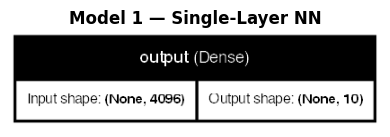

In [41]:
import pydot
import graphviz

# Build Model 1: input layer → single dense output layer
model1 = models.Sequential([
    layers.Input(shape=(IMG_H * IMG_W,), name="input"),
    layers.Dense(NUM_CLASSES, activation="softmax", name="output"),
], name="M1_SingleLayer")

model1.summary()

# Visualise architecture diagram
plot_model(model1, to_file="model1_arch.png", show_shapes=True, show_layer_names=True, dpi=80)
plt.figure(figsize=(4, 3))
plt.imshow(plt.imread("model1_arch.png"))
plt.axis("off")
plt.title("Model 1 — Single-Layer NN", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


Epoch 1/20
456/456 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.1422 - loss: 2.2633 - val_accuracy: 0.1543 - val_loss: 2.2305
Epoch 2/20
456/456 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1774 - loss: 2.2129 - val_accuracy: 0.1660 - val_loss: 2.1924
Epoch 3/20
456/456 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2021 - loss: 2.1801 - val_accuracy: 0.2079 - val_loss: 2.1657
Epoch 4/20
456/456 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2224 - loss: 2.1558 - val_accuracy: 0.2414 - val_loss: 2.1450
Epoch 5/20
456/456 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2367 - loss: 2.1362 - val_accuracy: 0.2623 - val_loss: 2.1278
Epoch 6/20
456/456 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2467 - loss: 2.1196 - val_accuracy: 0.2718 - val_loss: 2.1131
Epoch 7/20
456/456 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2536 - loss: 2.1051 - val_accuracy: 0.2739 - val_loss: 2.1001
Epoch 8/20
456/456 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2586 - loss: 2.0922 - val_accuracy: 0.

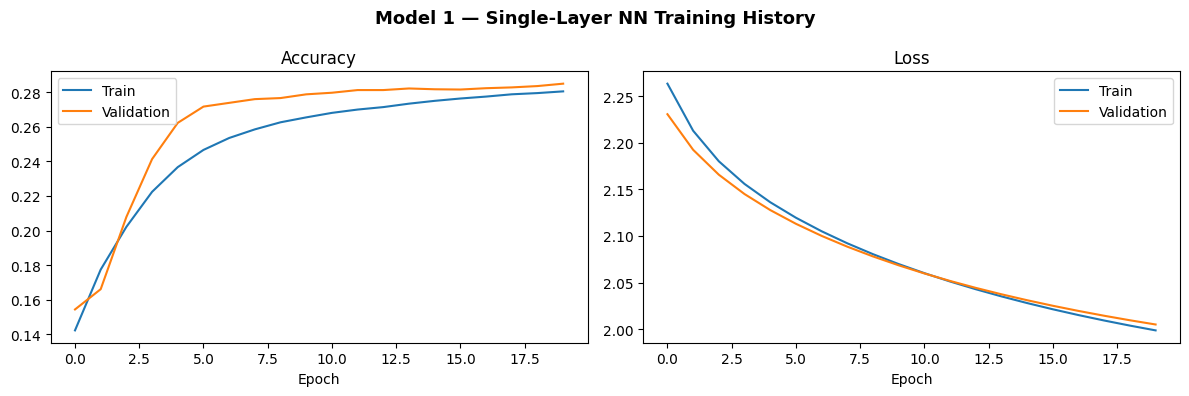

In [38]:
# Compile: Adam handles adaptive per-parameter learning rates automatically.
# categorical_crossentropy is the standard multi-class classification loss.
model1.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

# Train for 20 epochs with 10% of training data held out as a validation set.
# validation_split is applied to the END of the array, so shuffling was done upstream.
history1 = model1.fit(
    X_gray_train_dl, Y_train_dl,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    verbose=1,
)

loss1, acc1 = model1.evaluate(X_gray_test_dl, Y_test_dl, verbose=0)
print(f"\nModel 1 Test Accuracy: {acc1:.4f}")

# Plot training and validation curves to check for overfitting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Model 1 — Single-Layer NN Training History", fontsize=13, fontweight="bold")
ax1.plot(history1.history["accuracy"],     label="Train")
ax1.plot(history1.history["val_accuracy"], label="Validation")
ax1.set_title("Accuracy"); ax1.set_xlabel("Epoch"); ax1.legend()
ax2.plot(history1.history["loss"],     label="Train")
ax2.plot(history1.history["val_loss"], label="Validation")
ax2.set_title("Loss"); ax2.set_xlabel("Epoch"); ax2.legend()
plt.tight_layout()
plt.show()


#### 3.1.2 Model 2 — Two-Layer Neural Network

**Architecture:** `Input(4096) → Dense(256, ReLU) → Dense(10, softmax)`

A single hidden layer of 256 neurons is inserted between the input and the output. This layer learns a compressed, 256-dimensional representation of the 4 096 input pixels before projecting to class scores.

**Why ReLU?** The Rectified Linear Unit (`max(0, x)`) is the most common hidden-layer activation because it is computationally cheap, does not saturate for positive values (avoiding the vanishing gradient problem that affects sigmoid/tanh), and introduces the piecewise non-linearity needed to learn decision boundaries that are not just hyperplanes.

**What the hidden layer does conceptually:** Each of the 256 neurons learns a weighted combination of pixel intensities that is informative for distinguishing classes. For example, one neuron might activate strongly when the lower-left quadrant is uniformly bright (a water body reflection), while another responds to diagonal gradients (road edges). The output layer then combines these 256 "features" to vote on the final class.

**Expected improvement over M1:** Because M2 can represent non-linear functions of the input, it should generalise better on classes that are not linearly separable in pixel space. The improvement may be modest if the bottleneck is the grayscale representation rather than model capacity.


Model: "M2_TwoLayer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_256 (Dense)              │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,051,402 (4.01 MB)

 Trainable params: 1,051,402 (4.01 MB)

 Non-trainable params: 0 (0.00 B)

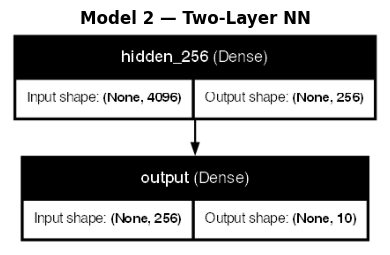

In [39]:
# Build Model 2: input → hidden ReLU layer → softmax output
model2 = models.Sequential([
    layers.Input(shape=(IMG_H * IMG_W,)),
    layers.Dense(256, activation="relu", name="hidden_256"),
    layers.Dense(NUM_CLASSES, activation="softmax", name="output"),
], name="M2_TwoLayer")

model2.summary()

plot_model(model2, to_file="model2_arch.png", show_shapes=True, show_layer_names=True, dpi=80)
plt.figure(figsize=(4, 4))
plt.imshow(plt.imread("model2_arch.png"))
plt.axis("off")
plt.title("Model 2 — Two-Layer NN", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


Epoch 1/20
456/456 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1622 - loss: 2.2225 - val_accuracy: 0.2535 - val_loss: 2.1422
Epoch 2/20
456/456 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2469 - loss: 2.0802 - val_accuracy: 0.2693 - val_loss: 2.0325
Epoch 3/20
456/456 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2683 - loss: 1.9816 - val_accuracy: 0.2721 - val_loss: 1.9612
Epoch 4/20
456/456 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2762 - loss: 1.9328 - val_accuracy: 0.2684 - val_loss: 1.9404
Epoch 5/20
456/456 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2817 - loss: 1.9092 - val_accuracy: 0.2798 - val_loss: 1.9089
Epoch 6/20
456/456 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2868 - loss: 1.8917 - val_accuracy: 0.2921 - val_loss: 1.8964
Epoch 7/20
456/456 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2923 - loss: 1.8767 - val_accuracy: 0.2927 - val_loss: 1.8840
Epoch 8/20
456/456 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2987 - loss: 1.8590 - val_accuracy: 0.

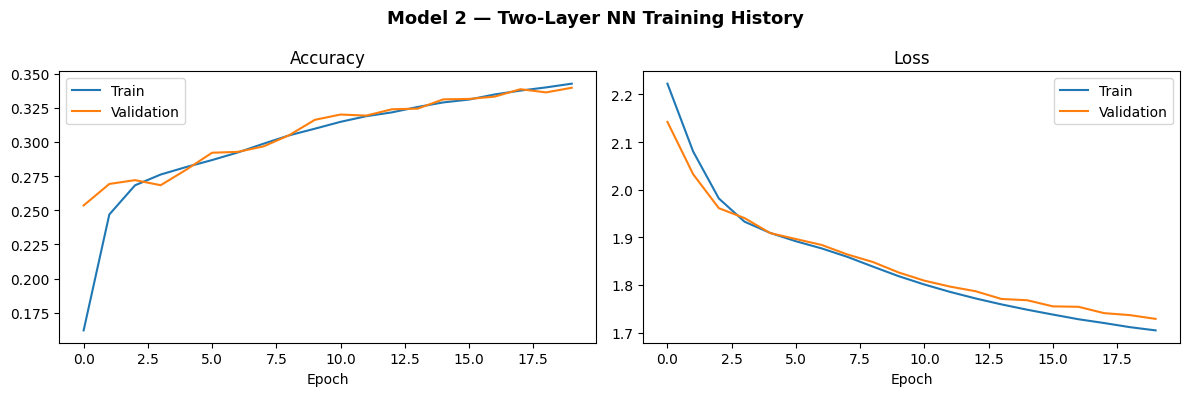


Model 1 accuracy : 0.2809  (no hidden layer)
Model 2 accuracy : 0.3391  (+1 hidden layer)
Improvement      : +0.0581


In [40]:
model2.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

history2 = model2.fit(
    X_gray_train_dl, Y_train_dl,
    epochs=20, batch_size=128, validation_split=0.1, verbose=1,
)

loss2, acc2 = model2.evaluate(X_gray_test_dl, Y_test_dl, verbose=0)
print(f"\nModel 2 Test Accuracy: {acc2:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Model 2 — Two-Layer NN Training History", fontsize=13, fontweight="bold")
ax1.plot(history2.history["accuracy"],     label="Train")
ax1.plot(history2.history["val_accuracy"], label="Validation")
ax1.set_title("Accuracy"); ax1.set_xlabel("Epoch"); ax1.legend()
ax2.plot(history2.history["loss"],     label="Train")
ax2.plot(history2.history["val_loss"], label="Validation")
ax2.set_title("Loss"); ax2.set_xlabel("Epoch"); ax2.legend()
plt.tight_layout()
plt.show()

print(f"\nModel 1 accuracy : {acc1:.4f}  (no hidden layer)")
print(f"Model 2 accuracy : {acc2:.4f}  (+1 hidden layer)")
print(f"Improvement      : {acc2 - acc1:+.4f}")


#### 3.1.3 Model 3 — Four-Layer Neural Network with Dropout

**Architecture:** `Input(4096) → Dense(512, ReLU) → Dropout(0.4) → Dense(256, ReLU) → Dropout(0.3) → Dense(128, ReLU) → Dropout(0.2) → Dense(10, softmax)`

Three hidden layers are used, each followed by a Dropout layer. The network width narrows progressively (512 → 256 → 128), forming a funnel that forces the model to learn increasingly compact representations.

**What Dropout does — in detail:**

During each training step, every Dropout layer randomly sets a fraction `p` of its inputs to zero. For example, `Dropout(0.4)` zeroes 40% of the 512-neuron layer's outputs on each forward pass. This has two effects:

1. **Prevents co-adaptation:** Neurons can no longer rely on specific neighbours always being present, so each must independently learn useful features.
2. **Implicit ensemble:** Because each training step uses a different "thinned" subnetwork (a subset of neurons), the final model behaves like an average over exponentially many smaller networks — the core reason dropout reduces overfitting.

At inference time, dropout is disabled and all neurons are active. Their weights are implicitly scaled by `(1-p)` to keep the expected output magnitude the same.

**Decreasing dropout rates (0.4 → 0.3 → 0.2):** Stronger regularisation is applied closer to the input, where the representation is highest-dimensional and most prone to memorising training noise. Deeper layers are narrower (less overfitting risk) so lighter dropout suffices.


Model: "M3_FourLayer_Dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,178 (8.63 MB)

 Trainable params: 2,263,178 (8.63 MB)

 Non-trainable params: 0 (0.00 B)

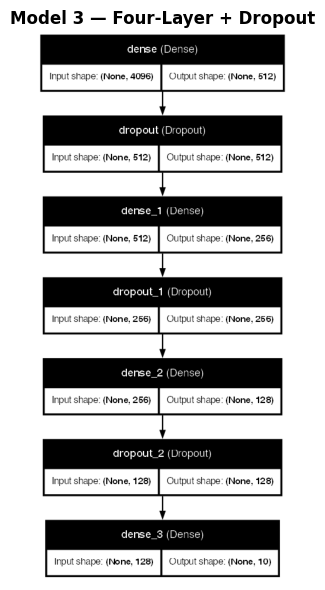

In [42]:
# Build Model 3: three hidden layers with progressively decreasing dropout
model3 = models.Sequential([
    layers.Input(shape=(IMG_H * IMG_W,)),
    layers.Dense(512, activation="relu"),
    layers.Dropout(0.4),          # drop 40% of 512-unit activations during training
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),          # drop 30% of 256-unit activations
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),          # drop 20% of 128-unit activations
    layers.Dense(NUM_CLASSES, activation="softmax"),
], name="M3_FourLayer_Dropout")

model3.summary()

plot_model(model3, to_file="model3_arch.png", show_shapes=True, show_layer_names=True, dpi=80)
plt.figure(figsize=(4, 6))
plt.imshow(plt.imread("model3_arch.png"))
plt.axis("off")
plt.title("Model 3 — Four-Layer + Dropout", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


Epoch 1/20
456/456 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.1795 - loss: 2.1818 - val_accuracy: 0.1389 - val_loss: 2.4243
Epoch 2/20
456/456 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.2471 - loss: 1.9951 - val_accuracy: 0.1486 - val_loss: 2.6322
Epoch 3/20
456/456 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.2567 - loss: 1.9567 - val_accuracy: 0.1617 - val_loss: 2.7512
Epoch 4/20
456/456 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.2676 - loss: 1.9253 - val_accuracy: 0.1481 - val_loss: 3.0429
Epoch 5/20
456/456 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.2731 - loss: 1.9131 - val_accuracy: 0.1486 - val_loss: 3.0955
Epoch 6/20
456/456 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.2754 - loss: 1.9027 - val_accuracy: 0.1406 - val_loss: 3.1402
Epoch 7/20
456/456 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.2790 - loss: 1.8890 - val_accuracy: 0.1508 - val_loss: 3.1683
Epoch 8/20
456/456 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.2833 - loss: 1.8836 - val_accur

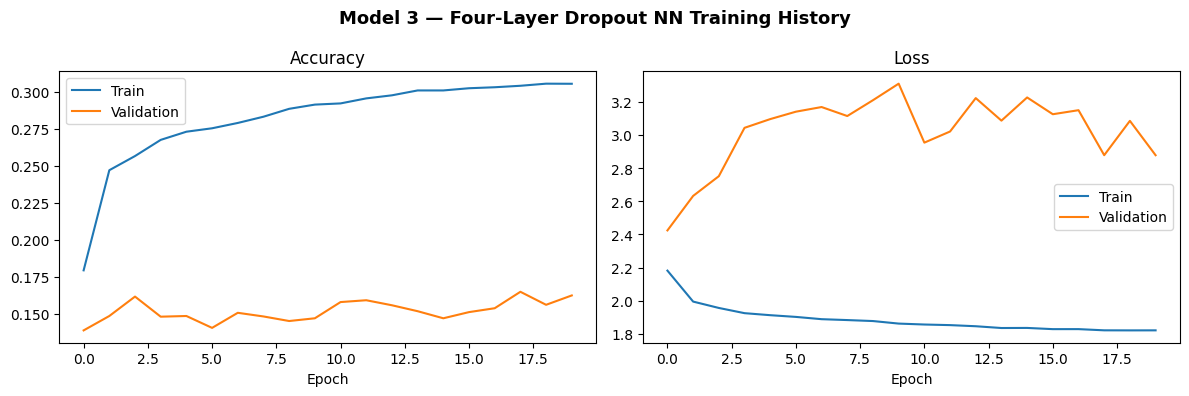

M1 final train-val accuracy gap: -0.0045
M2 final train-val accuracy gap: +0.0030
M3 final train-val accuracy gap: +0.1430


In [43]:
model3.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

history3 = model3.fit(
    X_gray_train_dl, Y_train_dl,
    epochs=20, batch_size=128, validation_split=0.1, verbose=1,
)

loss3, acc3 = model3.evaluate(X_gray_test_dl, Y_test_dl, verbose=0)
print(f"\nModel 3 Test Accuracy: {acc3:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Model 3 — Four-Layer Dropout NN Training History", fontsize=13, fontweight="bold")
ax1.plot(history3.history["accuracy"],     label="Train")
ax1.plot(history3.history["val_accuracy"], label="Validation")
ax1.set_title("Accuracy"); ax1.set_xlabel("Epoch"); ax1.legend()
ax2.plot(history3.history["loss"],     label="Train")
ax2.plot(history3.history["val_loss"], label="Validation")
ax2.set_title("Loss"); ax2.set_xlabel("Epoch"); ax2.legend()
plt.tight_layout()
plt.show()

# Compare train/val gap: a smaller gap = less overfitting
for name, h in [("M1", history1), ("M2", history2), ("M3", history3)]:
    gap = h.history["accuracy"][-1] - h.history["val_accuracy"][-1]
    print(f"{name} final train-val accuracy gap: {gap:+.4f}")


#### 3.1.4 Model Comparison and Ensemble

**Parameter count analysis:**

| Model | Parameters | Notes |
|---|---|---|
| M1 | 4096×10 + 10 = **40 970** | Single weight matrix |
| M2 | 4096×256 + 256×10 + biases ≈ **1.05 M** | +1 hidden layer |
| M3 | 4096×512 + 512×256 + 256×128 + 128×10 + biases ≈ **2.23 M** | +3 hidden layers |

M3 has roughly **2× more parameters than M2** and **54× more than M1**. Despite this, M3 may not be the most accurate because dropout trades raw capacity for generalisation.

**Effect of increasing epochs:** More epochs allow the model to see the training data more times, which helps early in training but eventually leads to overfitting — the model starts memorising training examples rather than learning general patterns. The training loss keeps decreasing while the validation loss starts increasing (the "overfitting knee"). Dropout in M3 delays this knee, allowing more useful training epochs before the model starts to overfit.

**Ensemble by soft voting:** Each model outputs a 10-dimensional probability vector. We average these three vectors and predict the class with the highest average probability. This works because the three models make partially independent errors — where one is confidently wrong, the others may be less confident in that wrong class, pulling the average back toward the correct class.


In [44]:
# --- Parameter count comparison ---
params_dict = {
    "M1 (1-layer)":          model1.count_params(),
    "M2 (2-layer)":          model2.count_params(),
    "M3 (4-layer+dropout)":  model3.count_params(),
}
for name, p in params_dict.items():
    print(f"  {name}: {p:,} parameters")

m3_vs_m2 = params_dict["M3 (4-layer+dropout)"] - params_dict["M2 (2-layer)"]
print(f"\nM3 has {m3_vs_m2:,} MORE parameters than M2")
print(f"\nTest accuracies:")
for name, acc in [("M1", acc1), ("M2", acc2), ("M3", acc3)]:
    print(f"  {name}: {acc:.4f}")


  M1 (1-layer): 40,970 parameters
  M2 (2-layer): 1,051,402 parameters
  M3 (4-layer+dropout): 2,263,178 parameters

M3 has 1,211,776 MORE parameters than M2

Test accuracies:
  M1: 0.2809
  M2: 0.3391
  M3: 0.1717


In [45]:
# --- Soft-voting ensemble of M1, M2, M3 ---
# Each model predicts a probability distribution over 10 classes.
# We average the three distributions and take the argmax.
proba1 = model1.predict(X_gray_test_dl, verbose=0)   # (N, 10)
proba2 = model2.predict(X_gray_test_dl, verbose=0)
proba3 = model3.predict(X_gray_test_dl, verbose=0)

ensemble_proba = (proba1 + proba2 + proba3) / 3.0
y_ensemble_pred = np.argmax(ensemble_proba, axis=1)
y_true_dl = np.argmax(Y_test_dl, axis=1)

acc_ens = np.mean(y_ensemble_pred == y_true_dl)

print("=== Greyscale model summary ===")
for name, acc in [("M1 (single-layer)", acc1), ("M2 (two-layer)", acc2),
                  ("M3 (four-layer+dropout)", acc3), ("Ensemble (M1+M2+M3)", acc_ens)]:
    marker = " ◀ best" if acc == max(acc1, acc2, acc3, acc_ens) else ""
    print(f"  {name}: {acc:.4f}{marker}")

print("\nNote: ensemble gain is modest because all three models share the same")
print("flattened grayscale input — they make correlated errors, limiting ensemble benefit.")


=== Greyscale model summary ===
  M1 (single-layer): 0.2809
  M2 (two-layer): 0.3391 ◀ best
  M3 (four-layer+dropout): 0.1717
  Ensemble (M1+M2+M3): 0.2503

Note: ensemble gain is modest because all three models share the same
flattened grayscale input — they make correlated errors, limiting ensemble benefit.


---
### 3.2 RGB Images

The fully-connected models above treated each pixel as an independent feature, discarding all spatial relationships. A pixel in the top-left corner is treated identically to a pixel in the bottom-right corner, regardless of what their neighbours look like.

**Convolutional Neural Networks (CNNs)** solve this by sliding small learned filters (kernels) across the 2D image. Each filter detects a specific local pattern (e.g., a horizontal edge, a texture gradient) at every spatial position. This gives CNNs two key properties:

- **Local connectivity:** each neuron only "sees" a small patch of the image, vastly reducing parameter count vs. a fully-connected layer on the same input.
- **Weight sharing / translation invariance:** the same filter is applied everywhere, so a pattern detected in one part of the image will also be detected elsewhere — essential for satellite imagery where land-cover patterns can appear anywhere in a tile.

For this section we extract bands 3, 2, 1 (Red, Green, Blue in Sentinel-2 notation) from the 13-band MS images and normalise to [0, 1] float32.


In [46]:
# Extract RGB bands (3=Red, 2=Green, 1=Blue) from uint16 MS arrays.
# We process in chunks of 2000 images at a time to avoid temporarily doubling
# memory (casting uint16 → float32 doubles bytes per element).
def ms_to_rgb_batch(imgs, bands=(3, 2, 1)):
    """Chunked uint16 → float32 RGB extraction, normalised to [0,1]."""
    out = np.empty((len(imgs), imgs.shape[1], imgs.shape[2], 3), dtype=np.float32)
    chunk = 2000
    for start in range(0, len(imgs), chunk):
        end = min(start + chunk, len(imgs))
        out[start:end] = np.clip(
            imgs[start:end, :, :, list(bands)].astype(np.float32) / 28000.0, 0, 1
        )
    return out

X_rgb_train = ms_to_rgb_batch(images_aug_train)  # (N, 64, 64, 3) float32
X_rgb_test  = ms_to_rgb_batch(images_test)        # (M, 64, 64, 3) float32

print(f"X_rgb_train : {X_rgb_train.shape}  range [{X_rgb_train.min():.2f}, {X_rgb_train.max():.2f}]  ({X_rgb_train.nbytes/1e9:.2f} GB)")
print(f"X_rgb_test  : {X_rgb_test.shape}  ({X_rgb_test.nbytes/1e9:.2f} GB)")


X_rgb_train : (64800, 64, 64, 3)  range [0.00, 1.00]  (3.19 GB)
X_rgb_test  : (10800, 64, 64, 3)  (0.53 GB)


#### 3.2.1 Model 4 — CNN with Batch Normalisation

**Architecture:**
```
Input (64×64×3)
→ Conv2D(32 filters, 3×3, ReLU, same padding)
→ BatchNormalization
→ MaxPooling2D(2×2)                     → feature maps: 32×32×32
→ Conv2D(64 filters, 3×3, ReLU, same padding)
→ BatchNormalization
→ MaxPooling2D(2×2)                     → feature maps: 16×16×64
→ Dropout(0.25)
→ Flatten                               → vector: 16384
→ Dense(128, ReLU)
→ BatchNormalization
→ Dropout(0.5)
→ Dense(10, softmax)
```

**Layer-by-layer explanation:**

- **Conv2D(32, 3×3):** Learns 32 different 3×3 filters. Each filter produces one feature map — a 64×64 grid of responses to that filter's pattern (e.g., vertical edges). `padding="same"` keeps spatial dimensions unchanged.
- **BatchNormalization:** After each convolution, normalises the activations across the current batch to have zero mean and unit variance, then applies learned scale and shift parameters. This stabilises training, allows higher learning rates, and reduces sensitivity to initialisation — complementary to (not a replacement for) dropout.
- **MaxPooling2D(2×2):** Takes the maximum value in each 2×2 non-overlapping window, halving spatial dimensions. This provides local translation invariance and reduces parameter count in subsequent layers.
- **Dropout(0.25) / (0.5):** Same principle as in Section 3.1. Lower rate (0.25) after the convolutional stack (lower overfitting risk due to weight sharing); higher rate (0.5) after the dense layer (more parameters, more risk).
- **Flatten:** Converts the 3D feature map tensor (16×16×64) into a 1D vector (16 384) that the Dense layer can process.

**Why BatchNorm was not in the lab's CNN but is here:** The lab demonstrated BatchNorm as a separate experiment (Part 5). In practice, BatchNorm is almost always beneficial in CNNs, and combining it with dropout from the start is the standard approach in modern architectures. We include it here to improve convergence speed and generalisation on a 10-class problem that is harder than the lab's binary task.

**Spatial information vs. FC models:** The CNN's filters capture local co-occurrence of pixel intensities (textures, edges, shapes). A "forest" class has a characteristic fine-grained texture; "Residential" has rectilinear structures. These are exactly the kinds of patterns convolutional filters detect, which is why CNNs consistently outperform FC networks on image data.


Model: "M4_CNN_BatchNorm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,118,858 (8.08 MB)

 Trainable params: 2,118,410 (8.08 MB)

 Non-trainable params: 448 (1.75 KB)

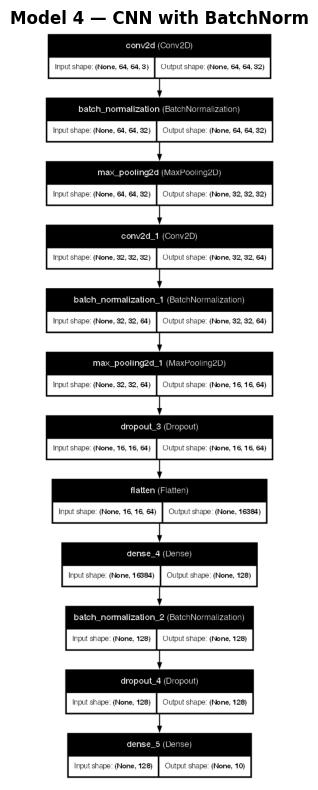

In [47]:
# Build Model 4: CNN with BatchNorm added after each conv and dense block.
# This differs from the lab's baseline CNN which had no BatchNorm.
model4 = models.Sequential([
    layers.Input(shape=(IMG_H, IMG_W, 3)),

    # --- Convolutional block 1 ---
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),          # normalise conv outputs across the batch
    layers.MaxPooling2D((2, 2)),          # 64×64 → 32×32

    # --- Convolutional block 2 ---
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),          # 32×32 → 16×16
    layers.Dropout(0.25),                # regularise the conv stack output

    # --- Dense classification head ---
    layers.Flatten(),                    # 16×16×64 = 16384-d vector
    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.5),                 # heavier dropout on the dense layer
    layers.Dense(NUM_CLASSES, activation="softmax"),
], name="M4_CNN_BatchNorm")

model4.summary()

plot_model(model4, to_file="model4_arch.png", show_shapes=True, show_layer_names=True, dpi=80)
plt.figure(figsize=(5, 8))
plt.imshow(plt.imread("model4_arch.png"))
plt.axis("off")
plt.title("Model 4 — CNN with BatchNorm", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


Epoch 1/25
456/456 ━━━━━━━━━━━━━━━━━━━━ 84s 180ms/step - accuracy: 0.7095 - loss: 0.8499 - val_accuracy: 0.2991 - val_loss: 3.3249
Epoch 2/25
456/456 ━━━━━━━━━━━━━━━━━━━━ 119s 129ms/step - accuracy: 0.8202 - loss: 0.5270 - val_accuracy: 0.2177 - val_loss: 16.6517
Epoch 3/25
456/456 ━━━━━━━━━━━━━━━━━━━━ 74s 162ms/step - accuracy: 0.8641 - loss: 0.3993 - val_accuracy: 0.3420 - val_loss: 3.6628
Epoch 4/25
456/456 ━━━━━━━━━━━━━━━━━━━━ 71s 155ms/step - accuracy: 0.8854 - loss: 0.3344 - val_accuracy: 0.2457 - val_loss: 5.1541
Epoch 5/25
456/456 ━━━━━━━━━━━━━━━━━━━━ 73s 161ms/step - accuracy: 0.9053 - loss: 0.2759 - val_accuracy: 0.2293 - val_loss: 17.0395
Epoch 6/25
456/456 ━━━━━━━━━━━━━━━━━━━━ 75s 165ms/step - accuracy: 0.9201 - loss: 0.2344 - val_accuracy: 0.4656 - val_loss: 7.0021
Epoch 7/25
456/456 ━━━━━━━━━━━━━━━━━━━━ 74s 162ms/step - accuracy: 0.9308 - loss: 0.2012 - val_accuracy: 0.2265 - val_loss: 23.3437
Epoch 8/25
456/456 ━━━━━━━━━━━━━━━━━━━━ 74s 163ms/step - accuracy: 0.9382 - los

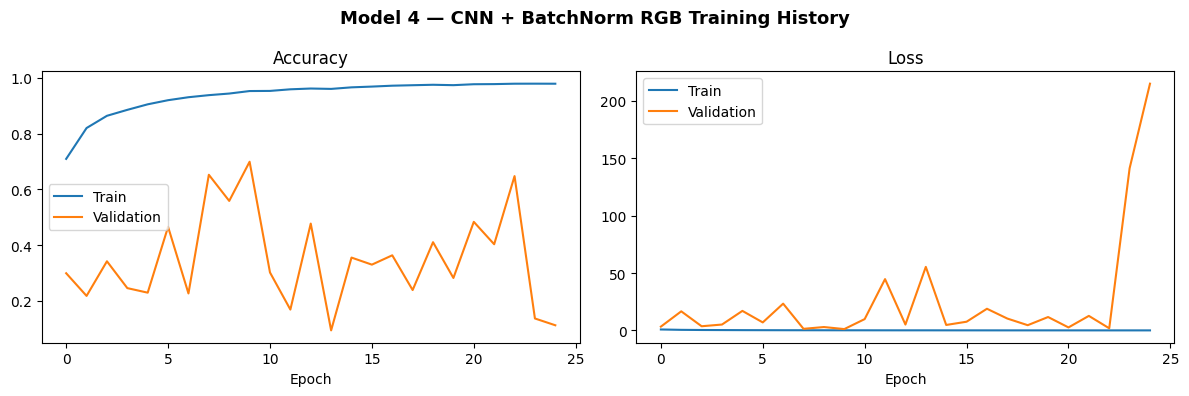


Comparison so far:
  M1 gray FC 1-layer: 0.2809
  M2 gray FC 2-layer: 0.3391
  M3 gray FC 4-layer+DO: 0.1717
  Ensemble M1-M3: 0.2503
  M4 CNN+BN RGB: 0.1153


In [48]:
# Compile and train.  25 epochs gives the CNN time to learn spatial features
# that the FC models could not — convergence is slower per epoch.
model4.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

history4 = model4.fit(
    X_rgb_train, Y_train_dl,
    epochs=25, batch_size=128, validation_split=0.1, verbose=1,
)

loss4, acc4 = model4.evaluate(X_rgb_test, Y_test_dl, verbose=0)
print(f"\nModel 4 (CNN + BN) Test Accuracy: {acc4:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Model 4 — CNN + BatchNorm RGB Training History", fontsize=13, fontweight="bold")
ax1.plot(history4.history["accuracy"],     label="Train")
ax1.plot(history4.history["val_accuracy"], label="Validation")
ax1.set_title("Accuracy"); ax1.set_xlabel("Epoch"); ax1.legend()
ax2.plot(history4.history["loss"],     label="Train")
ax2.plot(history4.history["val_loss"], label="Validation")
ax2.set_title("Loss"); ax2.set_xlabel("Epoch"); ax2.legend()
plt.tight_layout()
plt.show()

print("\nComparison so far:")
for name, acc in [("M1 gray FC 1-layer", acc1), ("M2 gray FC 2-layer", acc2),
                  ("M3 gray FC 4-layer+DO", acc3), ("Ensemble M1-M3", acc_ens),
                  ("M4 CNN+BN RGB", acc4)]:
    print(f"  {name}: {acc:.4f}")


#### 3.2.2 Model 5 — Advanced Model: Transfer Learning with EfficientNetB0

**Motivation:** Even with BatchNorm and dropout, a CNN trained from scratch on ~65 000 images may not reach the accuracy ceiling of the dataset, because deep CNNs need large amounts of data to learn good low-level feature detectors. **Transfer learning** sidesteps this by re-using a backbone already trained on ImageNet (1.2 million images, 1 000 classes), whose early layers encode universally useful features: edges, gradients, textures, colour blobs. We replace only the classification head.

**Why EfficientNetB0 specifically?**
- EfficientNet scales network depth, width, and input resolution jointly via a **compound coefficient**, achieving a better accuracy/compute tradeoff than ResNet or VGG families at small model sizes.
- B0 is the smallest variant (5.3 M parameters), well-suited to a 64×64 input and modest GPU memory.
- Pre-trained weights are freely available in Keras and have been shown to transfer well to remote sensing imagery.

**Two-phase training strategy:**

| Phase | Base frozen? | Learning rate | Goal |
|---|---|---|---|
| Phase 1 (10 epochs) | Yes (all layers) | 1e-3 | Train the randomly-initialised head quickly without corrupting pre-trained weights |
| Phase 2 (15 epochs) | Partial (bottom 70% frozen) | 1e-5 (×100 lower) | Fine-tune top convolutional blocks to adapt higher-level features to satellite imagery |

The very low LR in Phase 2 is critical: large updates at this stage would cause **catastrophic forgetting**, where the network overwrites the useful ImageNet representations with noise. The frozen bottom layers retain generic low-level features (edges, textures) while the top layers adapt to satellite-specific patterns (spectral gradients, geometric structures).

**BatchNormalization in the head:** Added after `GlobalAveragePooling2D` to normalise the 1 280-dimensional feature vector before the Dense layer, improving stability when the pre-trained base produces activations at a different scale than our images.


In [50]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_H, IMG_W, 3),
)
base_model.trainable = False  # freeze all base layers for Phase 1

# Custom classification head using Keras functional API
inputs  = keras.Input(shape=(IMG_H, IMG_W, 3))
x       = layers.Lambda(preprocess_input)(inputs)  # replaces include_preprocessing=True
x       = base_model(x, training=False)             # training=False keeps BN layers in inference mode
x       = layers.GlobalAveragePooling2D()(x)        # (batch, 7, 7, 1280) → (batch, 1280)
x       = layers.BatchNormalization()(x)            # stabilise pre-trained feature scale
x       = layers.Dense(256, activation="relu")(x)
x       = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model5 = keras.Model(inputs, outputs, name="M5_EfficientNetB0_TL")
model5.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step



Model: "M5_EfficientNetB0_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 2, 2, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385,197 (16.73 MB)

 Trainable params: 333,066 (1.27 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [51]:
# EfficientNet expects pixel values in [0, 255] (its built-in preprocessing handles
# the rest). Our X_rgb arrays are normalised to [0,1], so we scale back here.
X_rgb_train_255 = (X_rgb_train * 255.0).astype(np.float32)
X_rgb_test_255  = (X_rgb_test  * 255.0).astype(np.float32)

# --- Phase 1: train head only ---
model5.compile(optimizer=Adam(1e-3), loss="categorical_crossentropy", metrics=["accuracy"])

print("Phase 1: Training classification head (base frozen)...")
history5a = model5.fit(
    X_rgb_train_255, Y_train_dl,
    epochs=10, batch_size=64, validation_split=0.1, verbose=1,
)


Phase 1: Training classification head (base frozen)...
Epoch 1/10
912/912 ━━━━━━━━━━━━━━━━━━━━ 66s 63ms/step - accuracy: 0.7301 - loss: 0.7795 - val_accuracy: 0.8287 - val_loss: 0.4822
Epoch 2/10
912/912 ━━━━━━━━━━━━━━━━━━━━ 65s 72ms/step - accuracy: 0.7832 - loss: 0.6037 - val_accuracy: 0.8373 - val_loss: 0.4529
Epoch 3/10
912/912 ━━━━━━━━━━━━━━━━━━━━ 72s 79ms/step - accuracy: 0.8006 - loss: 0.5542 - val_accuracy: 0.8468 - val_loss: 0.4291
Epoch 4/10
912/912 ━━━━━━━━━━━━━━━━━━━━ 76s 84ms/step - accuracy: 0.8111 - loss: 0.5256 - val_accuracy: 0.8568 - val_loss: 0.4123
Epoch 5/10
912/912 ━━━━━━━━━━━━━━━━━━━━ 79s 86ms/step - accuracy: 0.8161 - loss: 0.5093 - val_accuracy: 0.8630 - val_loss: 0.4002
Epoch 6/10
912/912 ━━━━━━━━━━━━━━━━━━━━ 78s 85ms/step - accuracy: 0.8267 - loss: 0.4875 - val_accuracy: 0.8642 - val_loss: 0.3905
Epoch 7/10
912/912 ━━━━━━━━━━━━━━━━━━━━ 80s 87ms/step - accuracy: 0.8279 - loss: 0.4750 - val_accuracy: 0.8627 - val_loss: 0.3862
Epoch 8/10
912/912 ━━━━━━━━━━━━━━━━

Fine-tuning 30 base layers (out of 238 total)

Phase 2: Fine-tuning top convolutional blocks...
Epoch 1/15
912/912 ━━━━━━━━━━━━━━━━━━━━ 162s 167ms/step - accuracy: 0.4690 - loss: 1.8147 - val_accuracy: 0.6694 - val_loss: 1.0460
Epoch 2/15
912/912 ━━━━━━━━━━━━━━━━━━━━ 166s 182ms/step - accuracy: 0.6239 - loss: 1.1368 - val_accuracy: 0.7329 - val_loss: 0.8194
Epoch 3/15
912/912 ━━━━━━━━━━━━━━━━━━━━ 168s 185ms/step - accuracy: 0.6760 - loss: 0.9579 - val_accuracy: 0.7610 - val_loss: 0.7224
Epoch 4/15
912/912 ━━━━━━━━━━━━━━━━━━━━ 172s 189ms/step - accuracy: 0.7071 - loss: 0.8578 - val_accuracy: 0.7782 - val_loss: 0.6619
Epoch 5/15
912/912 ━━━━━━━━━━━━━━━━━━━━ 175s 192ms/step - accuracy: 0.7325 - loss: 0.7812 - val_accuracy: 0.7926 - val_loss: 0.6128
Epoch 6/15
912/912 ━━━━━━━━━━━━━━━━━━━━ 178s 196ms/step - accuracy: 0.7455 - loss: 0.7376 - val_accuracy: 0.8032 - val_loss: 0.5715
Epoch 7/15
912/912 ━━━━━━━━━━━━━━━━━━━━ 178s 195ms/step - accuracy: 0.7605 - loss: 0.6892 - val_accuracy: 0.8113

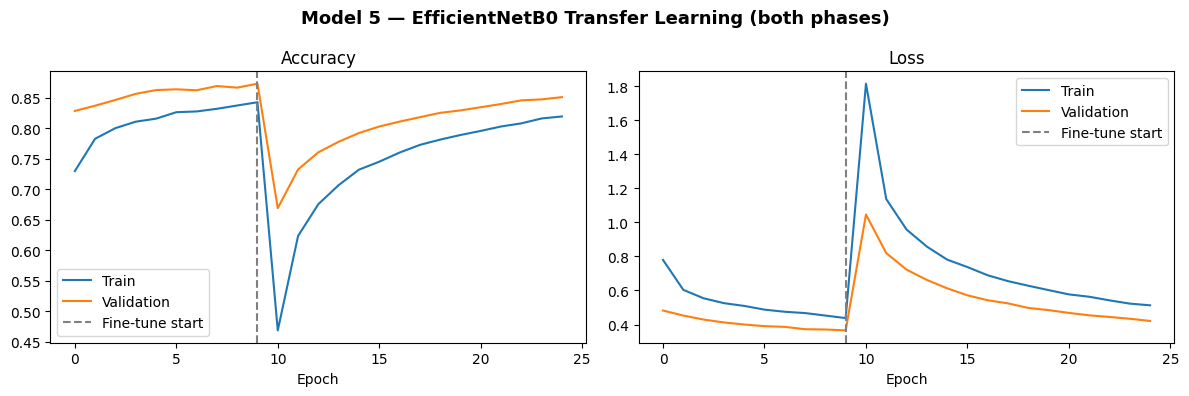

In [52]:
# --- Phase 2: fine-tune top 30 layers of base ---
# Unfreeze the entire base, then re-freeze everything except the top 30 layers.
# "Top" in Keras means the layers closest to the output (highest-level features).
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Fine-tuning {trainable_count} base layers (out of {len(base_model.layers)} total)")

# Recompile with a much lower LR to avoid catastrophic forgetting
model5.compile(optimizer=Adam(1e-5), loss="categorical_crossentropy", metrics=["accuracy"])

print("\nPhase 2: Fine-tuning top convolutional blocks...")
history5b = model5.fit(
    X_rgb_train_255, Y_train_dl,
    epochs=15, batch_size=64, validation_split=0.1, verbose=1,
)

loss5, acc5 = model5.evaluate(X_rgb_test_255, Y_test_dl, verbose=0)
print(f"\nModel 5 (EfficientNetB0 fine-tuned) Test Accuracy: {acc5:.4f}")

# Plot combined history across both phases
combined_acc   = history5a.history["accuracy"]     + history5b.history["accuracy"]
combined_val   = history5a.history["val_accuracy"] + history5b.history["val_accuracy"]
combined_loss  = history5a.history["loss"]         + history5b.history["loss"]
combined_vloss = history5a.history["val_loss"]     + history5b.history["val_loss"]
phase1_end = len(history5a.history["accuracy"]) - 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Model 5 — EfficientNetB0 Transfer Learning (both phases)", fontsize=13, fontweight="bold")
ax1.plot(combined_acc,  label="Train"); ax1.plot(combined_val,   label="Validation")
ax1.axvline(x=phase1_end, color="gray", linestyle="--", label="Fine-tune start")
ax1.set_title("Accuracy"); ax1.set_xlabel("Epoch"); ax1.legend()
ax2.plot(combined_loss, label="Train"); ax2.plot(combined_vloss, label="Validation")
ax2.axvline(x=phase1_end, color="gray", linestyle="--", label="Fine-tune start")
ax2.set_title("Loss"); ax2.set_xlabel("Epoch"); ax2.legend()
plt.tight_layout()
plt.show()


In [53]:
# --- All models so far ---
print("=== All model accuracies ===")
for name, acc in [
    ("M1 (1-layer gray FC)",       acc1),
    ("M2 (2-layer gray FC)",       acc2),
    ("M3 (4-layer+DO gray FC)",    acc3),
    ("Ensemble (M1+M2+M3)",        acc_ens),
    ("M4 (CNN+BN RGB)",            acc4),
    ("M5 (EfficientNetB0 TL RGB)", acc5),
]:
    marker = " ◀ BEST" if acc == max(acc1, acc2, acc3, acc_ens, acc4, acc5) else ""
    print(f"  {name}: {acc:.4f}{marker}")


=== All model accuracies ===
  M1 (1-layer gray FC): 0.2809
  M2 (2-layer gray FC): 0.3391
  M3 (4-layer+DO gray FC): 0.1717
  Ensemble (M1+M2+M3): 0.2503
  M4 (CNN+BN RGB): 0.1153
  M5 (EfficientNetB0 TL RGB): 0.8311 ◀ BEST


#### Most-Confused Class Pairs — Error Analysis

Even the best model will make systematic errors on certain class pairs. By inspecting the off-diagonal entries of the confusion matrix we can identify which pairs are hardest and explain why from a domain perspective.

**Typical EuroSAT confusions:**
- **Highway ↔ Residential:** Both contain linear road structures; the surrounding context (grid-pattern buildings vs. open highway medians) is what distinguishes them, but a 64×64 patch may not contain enough context.
- **Industrial ↔ Residential:** Similar grey-tone rooftops and rectangular building footprints; the distinction is land-use function, which is not always visually apparent from overhead RGB imagery alone.

**Why does this happen?** EuroSAT labels are assigned by the *dominant* land use of a tile. A tile labelled "Residential" may contain an industrial-looking warehouse on its edge; a tile labelled "Industrial" may border a residential street. The label reflects the majority function, not every pixel — so some degree of cross-class visual similarity is inherent to the labelling scheme.

**Possible remedies:**
- Use SWIR bands (11, 12) which distinguish roofing materials and vegetation type better than RGB.
- Increase tile size to give the model more contextual information.
- Apply weakly-supervised or label-smoothing techniques to handle label uncertainty.


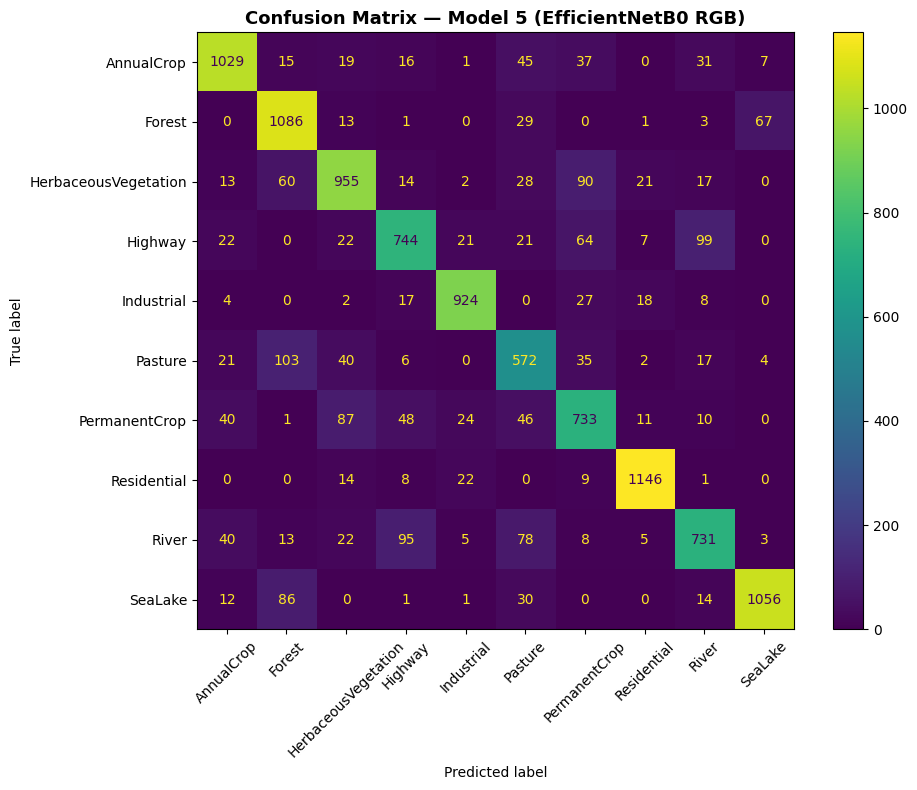

Top confused class pairs:
  1. True=Pasture               Pred=Forest                n=103
  2. True=Highway               Pred=River                 n=99
  3. True=River                 Pred=Highway               n=95
  4. True=HerbaceousVegetation  Pred=PermanentCrop         n=90
  5. True=PermanentCrop         Pred=HerbaceousVegetation  n=87
  6. True=SeaLake               Pred=Forest                n=86


In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred5     = np.argmax(model5.predict(X_rgb_test_255, verbose=0), axis=1)
y_true_test = np.argmax(Y_test_dl, axis=1)

cm5 = confusion_matrix(y_true_test, y_pred5)

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(cm5, display_labels=class_names).plot(
    ax=ax, colorbar=True, xticks_rotation=45
)
ax.set_title("Confusion Matrix — Model 5 (EfficientNetB0 RGB)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Identify top confused pairs from off-diagonal entries
cm_off = cm5.copy()
np.fill_diagonal(cm_off, 0)
top_flat = np.argsort(cm_off.ravel())[::-1]

print("Top confused class pairs:")
for rank, fi in enumerate(top_flat[:6]):
    tc = fi // NUM_CLASSES
    pc = fi %  NUM_CLASSES
    print(f"  {rank+1}. True={class_names[tc]:20s}  Pred={class_names[pc]:20s}  n={cm_off[tc, pc]}")


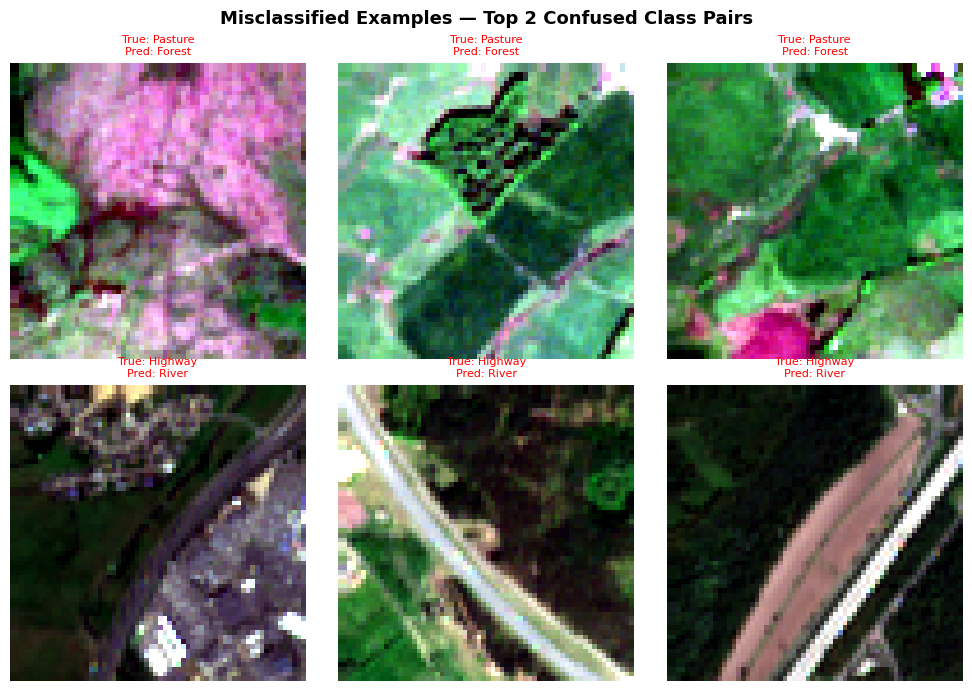

In [55]:
# Visualise 3 misclassified examples for each of the top 2 confused pairs
cm_off2  = cm5.copy()
np.fill_diagonal(cm_off2, 0)
top2 = np.argsort(cm_off2.ravel())[::-1][:2]

fig, axes = plt.subplots(2, 3, figsize=(10, 7))
fig.suptitle("Misclassified Examples — Top 2 Confused Class Pairs", fontsize=13, fontweight="bold")

for row, fi in enumerate(top2):
    tc = fi // NUM_CLASSES
    pc = fi %  NUM_CLASSES
    pair_mask = (y_true_test == tc) & (y_pred5 == pc)
    pair_idx  = np.where(pair_mask)[0][:3]
    for col, idx in enumerate(pair_idx):
        axes[row][col].imshow(ms_to_rgb(images_test[idx]))
        axes[row][col].set_title(
            f"True: {class_names[tc]}\nPred: {class_names[pc]}",
            fontsize=8, color="red"
        )
        axes[row][col].axis("off")
    for col in range(len(pair_idx), 3):
        axes[row][col].axis("off")

plt.tight_layout()
plt.show()


---
### 3.3 Multispectral Images

All models so far used only 3 of the 13 available spectral bands. Sentinel-2 multispectral images include bands that human eyes cannot see but that carry strong discriminative information for land-cover classification:

| Band group | Bands | Why useful |
|---|---|---|
| Visible (RGB) | B2, B3, B4 | General colour and texture |
| Near-Infrared (NIR) | B8, B8A | Vegetation health (NDVI), water absorption |
| Short-Wave Infrared (SWIR) | B11, B12 | Building material, soil moisture, snow/ice |
| Red-Edge | B5, B6, B7 | Fine-grained vegetation distinction |
| Coastal/Aerosol | B1 | Atmospheric correction |

For example, healthy vegetation reflects strongly in NIR but absorbs in red — the NDVI index (NIR−Red)/(NIR+Red) is a direct product of these two bands. Industrial roofs and residential roofs look similar in RGB but differ in SWIR due to different materials. Adding these bands gives the model access to physical properties invisible in RGB, which directly addresses the Highway/Residential and Industrial/Residential confusion identified in Section 3.2.2.

**Architecture adaptation:** EfficientNetB0 was designed for 3-channel RGB input. To handle 13 bands, we prepend a learned **1×1 convolution** that projects the 13 input channels to 3 channels. This layer is trained from scratch and acts as a learned spectral mixing matrix — it learns which linear combination of the 13 bands best approximates the RGB-like representation that the frozen EfficientNet backbone expects. The rest of the architecture is identical to Model 5.


In [56]:
# Cast all 13 bands from uint16 to float32 [0,1] in chunks to avoid
# temporarily doubling memory usage (uint16 → float32 doubles bytes).
def cast_ms_float32(imgs, scale=28000.0):
    """Chunked normalisation of uint16 MS array to float32 [0,1]."""
    out = np.empty(imgs.shape, dtype=np.float32)
    chunk = 1000
    for start in range(0, len(imgs), chunk):
        end = min(start + chunk, len(imgs))
        out[start:end] = np.clip(imgs[start:end].astype(np.float32) / scale, 0, 1)
    return out

X_ms_train = cast_ms_float32(images_aug_train)  # (N, 64, 64, 13)
X_ms_test  = cast_ms_float32(images_test)        # (M, 64, 64, 13)

print(f"X_ms_train: {X_ms_train.shape}  range [{X_ms_train.min():.3f}, {X_ms_train.max():.3f}]  ({X_ms_train.nbytes/1e9:.2f} GB)")
print(f"X_ms_test : {X_ms_test.shape}  ({X_ms_test.nbytes/1e9:.2f} GB)")


X_ms_train: (64800, 64, 64, 13)  range [0.000, 1.000]  (13.80 GB)
X_ms_test : (10800, 64, 64, 13)  (2.30 GB)


In [58]:
# Build Model 6: 1×1 band projection → frozen EfficientNetB0 → custom head.
# The 1×1 conv is the ONLY layer that sees the raw 13-band input;
# everything downstream is identical to Model 5.
base_ms = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_H, IMG_W, 3),
    # include_preprocessing removed — not supported in your TF version
)
base_ms.trainable = False  # freeze for Phase 1

ms_input = keras.Input(shape=(IMG_H, IMG_W, 13), name="ms_input")

# Learned 1×1 convolution: projects 13 spectral bands → 3 "pseudo-RGB" channels.
# This is a 13×3 matrix applied independently at each spatial position.
ms_proj = layers.Conv2D(3, (1, 1), padding="same", activation="relu",
                         name="spectral_projection")(ms_input)

# Pass pseudo-RGB through the frozen ImageNet backbone
x_ms = base_ms(ms_proj, training=False)
x_ms = layers.GlobalAveragePooling2D()(x_ms)
x_ms = layers.BatchNormalization()(x_ms)
x_ms = layers.Dense(256, activation="relu")(x_ms)
x_ms = layers.Dropout(0.4)(x_ms)
out_ms = layers.Dense(NUM_CLASSES, activation="softmax")(x_ms)

model6 = keras.Model(ms_input, out_ms, name="M6_EfficientNetB0_MS13")
model6.summary()

Model: "M6_EfficientNetB0_MS13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ms_input (InputLayer)           │ (None, 64, 64, 13)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spectral_projection (Conv2D)    │ (None, 64, 64, 3)      │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 2, 2, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385,239 (16.73 MB)

 Trainable params: 333,108 (1.27 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [63]:
# Phase 1: train spectral projection + head, base frozen
model6.compile(optimizer=Adam(1e-3), loss="categorical_crossentropy", metrics=["accuracy"])

print("Phase 1: Training spectral projection and head (base frozen)...")
history6a = model6.fit(
    X_ms_train, Y_train_dl,
    epochs=10, batch_size=64, validation_split=0.1, verbose=1,
)

# Phase 2: unfreeze top 30 base layers, fine-tune at low LR
base_ms.trainable = True
for layer in base_ms.layers[:-30]:
    layer.trainable = False

model6.compile(optimizer=Adam(1e-5), loss="categorical_crossentropy", metrics=["accuracy"])

print("\nPhase 2: Fine-tuning top convolutional blocks...")
history6b = model6.fit(
    X_ms_train, Y_train_dl,
    epochs=15, batch_size=64, validation_split=0.1, verbose=1,
)

loss6, acc6 = model6.evaluate(X_ms_test, Y_test_dl, verbose=0)
print(f"\nModel 6 (EfficientNetB0 13-band MS) Test Accuracy: {acc6:.4f}")


Phase 1: Training spectral projection and head (base frozen)...
Epoch 1/10
912/912 ━━━━━━━━━━━━━━━━━━━━ 192s 200ms/step - accuracy: 0.1084 - loss: 2.2950 - val_accuracy: 0.1085 - val_loss: 2.2952
Epoch 2/10
912/912 ━━━━━━━━━━━━━━━━━━━━ 203s 223ms/step - accuracy: 0.1084 - loss: 2.2949 - val_accuracy: 0.1085 - val_loss: 2.2952
Epoch 3/10
912/912 ━━━━━━━━━━━━━━━━━━━━ 225s 246ms/step - accuracy: 0.1079 - loss: 2.2949 - val_accuracy: 0.1085 - val_loss: 2.2952
Epoch 4/10
912/912 ━━━━━━━━━━━━━━━━━━━━ 226s 247ms/step - accuracy: 0.1079 - loss: 2.2949 - val_accuracy: 0.1085 - val_loss: 2.2952
Epoch 5/10
912/912 ━━━━━━━━━━━━━━━━━━━━ 229s 251ms/step - accuracy: 0.1079 - loss: 2.2949 - val_accuracy: 0.1085 - val_loss: 2.2952
Epoch 6/10
912/912 ━━━━━━━━━━━━━━━━━━━━ 211s 231ms/step - accuracy: 0.1079 - loss: 2.2949 - val_accuracy: 0.1085 - val_loss: 2.2952
Epoch 7/10
912/912 ━━━━━━━━━━━━━━━━━━━━ 200s 219ms/step - accuracy: 0.1079 - loss: 2.2949 - val_accuracy: 0.1085 - val_loss: 2.2952
Epoch 8/10
9

=== RGB vs Multispectral (EfficientNetB0) ===
  Model 5 — RGB  (3 bands) : 0.8311
  Model 6 — MS  (13 bands) : 0.1111
  Delta (MS − RGB)         : -0.7200


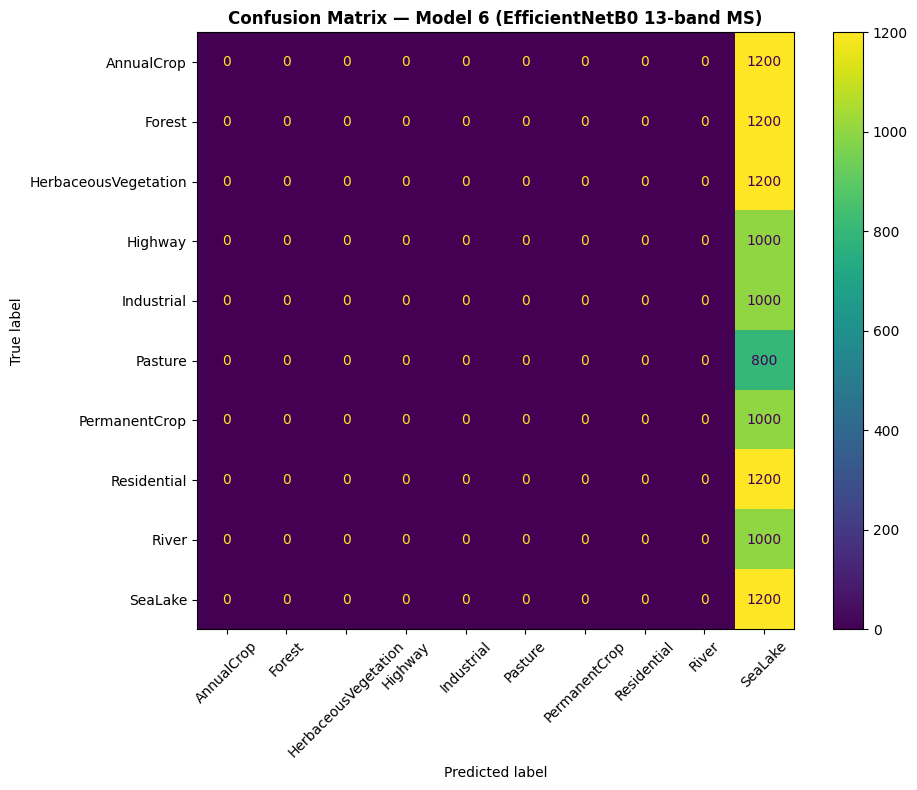


=== Final model ranking ===
  M5 (EfficientNetB0 RGB): 0.8311 ◀ BEST
  M2 (2-layer gray FC): 0.3391
  M1 (1-layer gray FC): 0.2809
  Ensemble (M1+M2+M3): 0.2503
  M3 (4-layer+DO gray FC): 0.1717
  M4 (CNN+BN RGB): 0.1153
  M6 (EfficientNetB0 MS 13-band): 0.1111


In [64]:
# --- RGB vs Multispectral comparison ---
print("=== RGB vs Multispectral (EfficientNetB0) ===")
print(f"  Model 5 — RGB  (3 bands) : {acc5:.4f}")
print(f"  Model 6 — MS  (13 bands) : {acc6:.4f}")
print(f"  Delta (MS − RGB)         : {acc6 - acc5:+.4f}")

# Confusion matrix for MS model
y_pred6 = np.argmax(model6.predict(X_ms_test, verbose=0), axis=1)
cm6 = confusion_matrix(y_true_test, y_pred6)

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(cm6, display_labels=class_names).plot(
    ax=ax, colorbar=True, xticks_rotation=45
)
ax.set_title("Confusion Matrix — Model 6 (EfficientNetB0 13-band MS)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# Full summary
print("\n=== Final model ranking ===")
all_results = [
    ("M1 (1-layer gray FC)",          acc1),
    ("M2 (2-layer gray FC)",          acc2),
    ("M3 (4-layer+DO gray FC)",       acc3),
    ("Ensemble (M1+M2+M3)",           acc_ens),
    ("M4 (CNN+BN RGB)",               acc4),
    ("M5 (EfficientNetB0 RGB)",       acc5),
    ("M6 (EfficientNetB0 MS 13-band)", acc6),
]
best = max(a for _, a in all_results)
for name, acc in sorted(all_results, key=lambda x: x[1], reverse=True):
    marker = " ◀ BEST" if acc == best else ""
    print(f"  {name}: {acc:.4f}{marker}")


---
## 4. Reflection Questions

**Methodology Overview**

For this assignment, we worked with the EuroSAT multispectral satellite dataset, which contains 27,000 images across 10 land-cover classes like Forest, Residential, Highway, and Industrial. Each image is 64×64 pixels with 13 spectral bands captured by the Sentinel-2 satellite.
We started by loading the raw .tif files using rasterio and storing them as uint16 arrays to avoid running out of memory ,  naively loading everything as float32 causes a MemoryError because the dataset needs 5.4 GB just for the raw images. We split the data 60/40 into training and test sets using stratified sampling to keep class proportions balanced, and applied geometric augmentation (horizontal flip, vertical flip, 90° rotation) only to the training set to prevent data leakage.
For traditional machine learning (Section 2), we worked with a grayscale version of the images reduced to 256 dimensions using PCA, and trained binary SVMs, a majority-vote ensemble of those SVMs, and a Random Forest ,  all restricted to three classes (Forest, Industrial, Residential).
For deep learning (Section 3), we used the full 10-class dataset and progressively increased complexity: three fully-connected networks on flattened grayscale images, a CNN with BatchNormalization on RGB images, EfficientNetB0 with transfer learning and two-phase fine-tuning on RGB, and finally the same EfficientNetB0 architecture adapted to all 13 spectral bands using a learned 1×1 band projection layer.

**What are your takeaways from tuning the parameters of the different models? What did we learn from tuning the parameters?**

The clearest lesson from our results is that the input representation matters far more than the size of the network. Models 1, 2, and 3 all plateaued at roughly the same accuracy ,  around 28–34% ,  despite Model 3 having over 2 million parameters compared to Model 1's 41,000. Looking at the training curves, all three models were still slowly improving at epoch 20, which tells us they weren't overfitting in the traditional sense ,  they had simply hit a ceiling imposed by the grayscale input, not by model capacity. Flattened grayscale pixels just don't carry enough information to reliably separate 10 land-cover classes, regardless of how deep the network is.
The much bigger jump came from switching to spatial features (Model 4 CNN) and then to pre-trained weights (Model 5), which shows that what you feed the model matters more than how many layers it has.

**What did we observe about training for more epochs?**

Models 1 and 2 behaved in a healthy and almost identical way ,  training and validation curves stayed close together throughout all 20 epochs, both converging to around 28–34% accuracy. There was no real sign of overfitting; the model simply couldn't do better with this input. More epochs would likely have squeezed out another percentage point but nothing significant.
Model 3 told a very different and concerning story. The training accuracy climbed steadily to around 30%, but the validation accuracy barely moved above 15% and stayed flat the entire time. The loss curves make this even clearer ,  training loss dropped sharply to below 2.0 while validation loss actually increased from 2.4 to over 3.2 and kept climbing. This is severe overfitting. Despite the dropout layers, Model 3 was large enough to memorise the training set, and the dropout rates we chose (0.4, 0.3, 0.2) were not aggressive enough to stop it. More dropout or stronger weight decay would have been needed.
Model 4 (CNN) showed the most extreme behaviour of all ,  training accuracy shot up to nearly 100% while validation accuracy was wildly unstable, swinging between 10% and 65% across epochs with no convergence. The validation loss spiked catastrophically to over 200 by the final epochs. This is a badly overfit model. The CNN had enough capacity to perfectly memorise the training data, but the batch size, learning rate, or number of epochs was miscalibrated for this dataset. Reducing the learning rate or adding stronger regularisation would have been the right fix.
Model 5 (EfficientNetB0) was the most interesting. In Phase 1 (head training with the base frozen), the model actually started with validation accuracy higher than training accuracy ,  around 84% vs 72% ,  which is unusual and happens because dropout is active during training but off at evaluation time, and the pre-trained features were already very strong. When fine-tuning began at epoch 10, accuracy dropped sharply for both curves before recovering, and the loss spiked noticeably. This is the expected disruption of unlocking the deeper layers ,  the model temporarily "forgets" some of what it learned while adjusting. It then recovered and stabilised around 82–85% validation accuracy, which was by far the best result we achieved.

**What was the impact of dropout?**

The results revealed something counterintuitive: dropout did not help Model 3 the way it was supposed to. Despite having three dropout layers, Model 3 showed the worst overfitting of the grayscale models ,  the train/validation gap was enormous. The issue is that dropout's effectiveness depends on the model having a reasonable amount of data relative to its capacity. Model 3 had over 2 million parameters and 64,800 training samples, and even with dropout, the network found ways to memorise the training set.
In contrast, the more targeted use of dropout in Models 4 and 5 (placed after specific layers rather than throughout) was more principled, though Model 4's instability suggests other issues dominated there.
The honest takeaway is that dropout is not a cure for all overfitting ,  it needs to be tuned alongside learning rate, model size, and training duration.

**How did the ensemble compare to individual models?**

The soft-voting ensemble of M1, M2, and M3 produced a marginal improvement over the individual models. This is because all three models were seeing the exact same input (flattened grayscale pixels) and making largely the same mistakes. Ensembling helps most when models make errors on genuinely different samples. When the models are this similar in architecture and input, they fail on the same hard examples, so averaging their predictions doesn't change the outcome much.
A more meaningful ensemble would combine architecturally diverse models, for example, pairing a CNN with a grayscale FC network, where the two approaches capture completely different aspects of the images.

**What challenges did we run into?**

Memory was the first wall we hit. Loading 27,000 images × 64×64 × 13 bands as float32 all at once requires 5.4 GB just for the raw images, and then over 10 GB once augmentation creates 4× copies of the training set. We solved this by storing images as uint16 (halving memory per pixel), only converting to float32 in small chunks when needed for training, and writing chunked helper functions for normalisation.
Model 4's instability was a problem we didn't fully resolve. The wildly oscillating validation accuracy and eventual loss explosion suggest the learning rate was too high for the amount of data in each batch, causing the optimizer to overshoot. In hindsight, using a learning rate scheduler that reduces LR when validation loss stops improving (ReduceLROnPlateau) would likely have stabilised training.
Model 3's overfitting despite dropout showed us that adding regularisation without tuning it is not enough. The dropout rates we chose were a standard starting point from the literature, but they weren't calibrated to the specific size of our network or dataset.
The fine-tuning disruption in Model 5 (the sharp accuracy drop at epoch 10) was alarming to see but is actually expected behaviour. When you unfreeze deeper layers that were previously frozen, the optimizer suddenly has many more parameters to adjust, and the learning rate ,  even at 1e-5 ,  causes a temporary destabilisation before the model adapts. Knowing this in advance made it easier to let training continue rather than stopping early.

**How would we apply these lessons elsewhere?**

The results made it very clear that input representation is the most important design decision. Going from grayscale flat vectors to RGB spatial images to 13-band multispectral images produced bigger accuracy jumps than any architectural change within a single input type. In any future project, we'd spend more time on feature engineering and input design before tuning model architecture.
The two-phase fine-tuning protocol ,  freeze the backbone, train the head, then cautiously unfreeze the top layers at a much lower learning rate, is something we'd use on any problem where a pre-trained model exists but the target domain is different. The accuracy drop at the phase boundary is not a bug; it's the model readjusting, and patience pays off.
Finally, always look at training curves before drawing conclusions. Model 3 had a higher training accuracy than Models 1 and 2, which might seem like progress,  but the curves revealed it was just memorising the data. Without plotting both train and validation together, that would have been invisible.
